In [1]:
###testing R in jyupter 
system("type R")

In [2]:
#package installation 
#install.packages("purrr")
#install.packages("tidyverse")
#conda install r-tidyverse r-purrr bioconductor-edger bioconductor-busparse bioconductor-rtracklayer r-dplyr -y 
#conda install -c conda-forge r-purrr -y
#conda install -c bioconda bioconductor-edger -y
#conda install -c bioconda bioconductor-busparse -y
#conda install -c bioconda bioconductor-rtracklayer -y
#conda install -c conda-forge r-dplyr -y 

In [3]:
library(purrr)
library(tidyverse)
library(edgeR)
library(rtracklayer)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

  

In [4]:
library(purrr)
library(tidyverse)
f_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "16.5.+featureCounts$", full.names = T)

f_files


[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts"
 [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts"
 [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts"
 [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts"        
 [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts"        
 [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts"        
 [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts"      
 [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts"      
 [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts"      
[10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts"    
[11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts"    
[12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts"    
[13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts"    
[14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts"    
[15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts"    
[16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts"  
[17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts"  
[18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts"  
[19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts"   
[20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts"   
[21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts"   
[22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts"      
[23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts"      
[24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts"      
[25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts"     
[26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts"     
[27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts"     
[28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts"     
[29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts"     
[30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.f

In [5]:
f_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.3.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts')

f_files

[1] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts"
 [2] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts"
 [3] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts"
 [4] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts"        
 [5] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts"        
 [6] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts"        
 [7] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts"      
 [8] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts"      
 [9] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts"      
[10] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts"    
[11] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts"    
[12] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts"    
[13] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts"    
[14] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts"    
[15] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts"    
[16] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts"  
[17] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts"  
[18] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts"  
[19] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts"   
[20] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts"   
[21] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts"   
[22] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts"      
[23] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts"      
[24] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts"      
[25] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts"     
[26] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts"     
[27] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts"     
[28] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts"     
[29] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts"     
[30] "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.f

In [6]:
samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames

[1] "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc" "129S1_SvImJ-16.5dpc"
 [4] "A_J-16.5dpc"         "A_J-16.5dpc"         "A_J-16.5dpc"        
 [7] "AKR_J-16.5dpc"       "AKR_J-16.5dpc"       "AKR_J-16.5dpc"      
[10] "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"     "BALB_cJ-16.5dpc"    
[13] "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"     "C3H_HeJ-16.5dpc"    
[16] "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"   "C57BL_6NJ-16.5dpc"  
[19] "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"    "CAST_EiJ-16.5dpc"   
[22] "CBA_J-16.5dpc"       "CBA_J-16.5dpc"       "CBA_J-16.5dpc"      
[25] "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"      "DBA_2J-16.5dpc"     
[28] "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"      "FVB_NJ-16.5dpc"     
[31] "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc"  "NOD_ShiLtJ-16.5dpc" 
[34] "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"     "PWK_PhJ-16.5dpc"    
[37] "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"   "SPRET_EiJ-16.5dpc"  
[40] "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"     "WSB_EiJ-16.5dpc"

In [7]:
samplenames <- c('129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','A_J-E16.5','A_J-E16.5','A_J-E16.5','AKR_J-E16.5',
'AKR_J-E16.5','AKR_J-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5','CBA_J-E16.5',
'CBA_J-E16.5','CBA_J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5')

In [8]:
#list of sample names with replicates 
lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))

lables

[1] "129S1_SvImJ-16.5dpc.1" "129S1_SvImJ-16.5dpc.2" "129S1_SvImJ-16.5dpc.3"
 [4] "A_J-16.5dpc.1"         "A_J-16.5dpc.2"         "A_J-16.5dpc.3"        
 [7] "AKR_J-16.5dpc.1"       "AKR_J-16.5dpc.2"       "AKR_J-16.5dpc.3"      
[10] "BALB_cJ-16.5dpc.1"     "BALB_cJ-16.5dpc.2"     "BALB_cJ-16.5dpc.3"    
[13] "C3H_HeJ-16.5dpc.1"     "C3H_HeJ-16.5dpc.2"     "C3H_HeJ-16.5dpc.3"    
[16] "C57BL_6NJ-16.5dpc.1"   "C57BL_6NJ-16.5dpc.2"   "C57BL_6NJ-16.5dpc.3"  
[19] "CAST_EiJ-16.5dpc.1"    "CAST_EiJ-16.5dpc.2"    "CAST_EiJ-16.5dpc.3"   
[22] "CBA_J-16.5dpc.1"       "CBA_J-16.5dpc.2"       "CBA_J-16.5dpc.3"      
[25] "DBA_2J-16.5dpc.1"      "DBA_2J-16.5dpc.2"      "DBA_2J-16.5dpc.3"     
[28] "FVB_NJ-16.5dpc.1"      "FVB_NJ-16.5dpc.2"      "FVB_NJ-16.5dpc.3"     
[31] "NOD_ShiLtJ-16.5dpc.1"  "NOD_ShiLtJ-16.5dpc.2"  "NOD_ShiLtJ-16.5dpc.3" 
[34] "PWK_PhJ-16.5dpc.1"     "PWK_PhJ-16.5dpc.2"     "PWK_PhJ-16.5dpc.3"    
[37] "SPRET_EiJ-16.5dpc.1"   "SPRET_EiJ-16.5dpc.2"   "SPRET_EiJ-16.5dpc.3"  
[40] "WSB_EiJ-16.5dpc.1"     "WSB_EiJ-16.5dpc.2"     "WSB_EiJ-16.5dpc.3"

In [9]:
lables <- c('129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3','A_J-E16.5.1',
'A_J-E16.5.2','A_J-E16.5.3','AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3','BALB_cJ-E16.5.1',
'BALB_cJ-E16.5.2','BALB_cJ-E16.5.3','C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3','C57BL_6NJ-E16.5.1',
'C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3','CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3','CBA_J-E16.5.1',
'CBA_J-E16.5.2','CBA_J-E16.5.3','DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3','FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3','SPRET_EiJ-E16.5.1',
'SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3','WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3')

In [10]:
#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
samplenames_order = c('C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5',
'BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5',
'A_J-E16.5','A_J-E16.5','A_J-E16.5',
'FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5',
'C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
'129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5',
'DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5',
'AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5',
'CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5',
'NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
'WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5',
'CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5',
'PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5',
'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5')

In [11]:
#list of sample names with replicates 
#lables = tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T))
lables_order = c('C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3',
'BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3',
'A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3',
'FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3',
'C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3',
'129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3',
'DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3',
'AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3',
'CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3',
'NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3',
'WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3',
'CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3',
'PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3',
'SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3')

In [12]:
A129S1_SvImJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/129S1_SvImJ_v3.2.gff3") #import gff3 file 
A129S1_SvImJ <- na.omit(mcols(A129S1_SvImJ)[,c("gene_id","Name",'type')])
A129S1_SvImJ <- A129S1_SvImJ[A129S1_SvImJ$type == 'gene', ]
A129S1_SvImJ
A129S1_SvImJ_geneName = A129S1_SvImJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A129S1_SvImJ_geneName) <- A129S1_SvImJ_geneName$gene_id
A129S1_SvImJ_geneName$gene_id <- NULL
A129S1_SvImJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts')
#A129S1_SvImJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
A129S1_SvImJ_samplenames = c('129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5')

A129S1_SvImJ_lables = c('129S1_SvImJ-E16.5.1','129S1_SvImJ-E16.5.2','129S1_SvImJ-E16.5.3')
A129S1_SvImJ_raw <- readDGE(A129S1_SvImJ_files, columns = c(1, 7), skip = 1, sep="\t", group= A129S1_SvImJ_samplenames, labels = A129S1_SvImJ_lables)

library(dplyr)
A129S1_SvImJ_raw$counts <- merge(x=A129S1_SvImJ_raw$counts, y=A129S1_SvImJ_geneName, by = 0,all.x=TRUE ) #left merge 
A129S1_SvImJ_raw$counts['Row.names'] <- NULL
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts[!is.na(A129S1_SvImJ_raw$counts$Name),] #remove NA 
A129S1_SvImJ_raw$counts <- A129S1_SvImJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A129S1_SvImJ_raw$counts <- as.data.frame(A129S1_SvImJ_raw$counts[!duplicated(A129S1_SvImJ_raw$counts$Name), ])  #remove dulicate values 
rownames(A129S1_SvImJ_raw$counts) <- A129S1_SvImJ_raw$counts$Name #set rawname to gene symbloes 
A129S1_SvImJ_raw$counts$Name <- NULL #remove genesybloe columns 
A129S1_SvImJ_raw

DataFrame with 20396 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00200002305        ugt1a1     gene
2     ENSMUSG00200002142          XKR4     gene
3     ENSMUSG00200001961           RP1     gene
4     ENSMUSG00200001998         SOX17     gene
5     ENSMUSG00200002527        MRPL15     gene
...                  ...           ...      ...
20392 ENSMUSG00200013771         AMELX     gene
20393 ENSMUSG00200013786          HCCS     gene
20394 ENSMUSG00200013810          rbmx     gene
20395 ENSMUSG00200013872          MID1     gene
20396 ENSMUSG00200013909 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                             files
129S1_SvImJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.1.featureCounts
129S1_SvImJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.2.featureCounts
129S1_SvImJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/129S1_SvImJ-16.5dpc.3.featureCounts
                                group lib.size norm.factors
129S1_SvImJ-E16.5.1 129S1_SvImJ-E16.5 31817792            1
129S1_SvImJ-E16.5.2 129S1_SvImJ-E16.5 36889870            1
129S1_SvImJ-E16.5.3 129S1_SvImJ-E16.5 36916967            1

$counts
              129S1_SvImJ-E16.5.1 129S1_SvImJ-E16.5.2 129S1_SvImJ-E16.5.3
0610007P14Rik             1680.50              1897.0             1647.00
0610009B22Rik              467.25               547.0              460.25
0610009O20Rik             1950.00              2251.5             2220.50
0610010F05Rik             1398.60              1751.5             1737.00
0610010K14Rik              996.50               995.0              945.00
19087 more rows ...

In [13]:
A_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/A_J_v3.2.gff3") #import gff3 file 
A_J <- na.omit(mcols(A_J)[,c("gene_id","Name",'type')])
A_J <- A_J[A_J$type == 'gene', ]
A_J
A_J_geneName = A_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(A_J_geneName) <- A_J_geneName$gene_id
A_J_geneName$gene_id <- NULL
A_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts')
#A_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "A_J.+.featureCounts$", full.names = T)
A_J_samplenames = c('A_J-E16.5','A_J-E16.5','A_J-E16.5')

A_J_lables = c('A_J-E16.5.1','A_J-E16.5.2','A_J-E16.5.3')
A_J_raw <- readDGE(A_J_files, columns = c(1, 7), skip = 1, sep="\t", group= A_J_samplenames, labels = A_J_lables)

library(dplyr)
A_J_raw$counts <- merge(x=A_J_raw$counts, y=A_J_geneName, by = 0,all.x=TRUE ) #left merge 
A_J_raw$counts['Row.names'] <- NULL
A_J_raw$counts <- A_J_raw$counts[!is.na(A_J_raw$counts$Name),] #remove NA 
A_J_raw$counts <- A_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

A_J_raw$counts <- as.data.frame(A_J_raw$counts[!duplicated(A_J_raw$counts$Name), ])  #remove dulicate values 
rownames(A_J_raw$counts) <- A_J_raw$counts$Name #set rawname to gene symbloes 
A_J_raw$counts$Name <- NULL #remove genesybloe columns 
A_J_raw

DataFrame with 20472 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00195002697          XKR4     gene
2     ENSMUSG00195002553           RP1     gene
3     ENSMUSG00195002578         SOX17     gene
4     ENSMUSG00195002659        MRPL15     gene
5     ENSMUSG00195002525        LYPLA1     gene
...                  ...           ...      ...
20468 ENSMUSG00195016023         AMELX     gene
20469 ENSMUSG00195016042          HCCS     gene
20470 ENSMUSG00195016074          rbmx     gene
20471 ENSMUSG00195015519          MID1     gene
20472 ENSMUSG00195015611 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                             files
A_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.1.featureCounts
A_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.2.featureCounts
A_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/A_J-16.5dpc.3.featureCounts
                group lib.size norm.factors
A_J-E16.5.1 A_J-E16.5 35246275            1
A_J-E16.5.2 A_J-E16.5 34330130            1
A_J-E16.5.3 A_J-E16.5 31912638            1

$counts
              A_J-E16.5.1 A_J-E16.5.2 A_J-E16.5.3
0610007P14Rik     6531.41     5648.35     5443.31
0610009B22Rik      504.00      473.00      440.00
0610009O20Rik     2068.00     1940.50     1958.75
0610010F05Rik     1532.05     1539.56     1399.74
0610010K14Rik     1219.00     1063.00      964.00
19097 more rows ...

In [14]:
AKR_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/AKR_J_v3.2.gff3") #import gff3 file 
AKR_J <- na.omit(mcols(AKR_J)[,c("gene_id","Name",'type')])
AKR_J <- AKR_J[AKR_J$type == 'gene', ]
AKR_J
AKR_J_geneName = AKR_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(AKR_J_geneName) <- AKR_J_geneName$gene_id
AKR_J_geneName$gene_id <- NULL
AKR_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts')
#AKR_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
AKR_J_samplenames = c('AKR_J-E16.5','AKR_J-E16.5','AKR_J-E16.5')

AKR_J_lables = c('AKR_J-E16.5.1','AKR_J-E16.5.2','AKR_J-E16.5.3')

AKR_J_raw <- readDGE(AKR_J_files, columns = c(1, 7), skip = 1, sep="\t", group= AKR_J_samplenames, labels = AKR_J_lables)
AKR_J_raw
library(dplyr)
AKR_J_raw$counts <- merge(x=AKR_J_raw$counts, y=AKR_J_geneName, by = 0,all.x=TRUE ) #left merge 
AKR_J_raw$counts['Row.names'] <- NULL
AKR_J_raw$counts <- AKR_J_raw$counts[!is.na(AKR_J_raw$counts$Name),] #remove NA 
AKR_J_raw$counts <- AKR_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

AKR_J_raw$counts <- as.data.frame(AKR_J_raw$counts[!duplicated(AKR_J_raw$counts$Name), ])  #remove dulicate values 
rownames(AKR_J_raw$counts) <- AKR_J_raw$counts$Name #set rawname to gene symbloes 
AKR_J_raw$counts$Name <- NULL #remove genesybloe columns 
AKR_J_raw

DataFrame with 20391 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00220003361          XKR4     gene
2     ENSMUSG00220003474           RP1     gene
3     ENSMUSG00220003489         SOX17     gene
4     ENSMUSG00220003074        MRPL15     gene
5     ENSMUSG00220003096        LYPLA1     gene
...                  ...           ...      ...
20387 ENSMUSG00220030338         AMELX     gene
20388 ENSMUSG00220030408          HCCS     gene
20389 ENSMUSG00220030465          rbmx     gene
20390 ENSMUSG00220010896          MID1     gene
20391 ENSMUSG00220010941 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                 files
AKR_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts
AKR_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts
AKR_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts
                    group lib.size norm.factors
AKR_J-E16.5.1 AKR_J-E16.5 30775896            1
AKR_J-E16.5.2 AKR_J-E16.5 34472536            1
AKR_J-E16.5.3 AKR_J-E16.5 34977957            1

$counts
                    Samples
Tags                 AKR_J-E16.5.1 AKR_J-E16.5.2 AKR_J-E16.5.3
  ENSMUSG00220004397          3.79          6.34         11.19
  ENSMUSG00220003652          0.00          0.00          0.00
  ENSMUSG00220003361       5762.74       7581.04       6927.47
  ENSMUSG00220003634         37.50         43.00         42.00
  ENSMUSG00220003640         25.00         39.50         32.00
25748 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                 files
AKR_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.1.featureCounts
AKR_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.2.featureCounts
AKR_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/AKR_J-16.5dpc.3.featureCounts
                    group lib.size norm.factors
AKR_J-E16.5.1 AKR_J-E16.5 30775896            1
AKR_J-E16.5.2 AKR_J-E16.5 34472536            1
AKR_J-E16.5.3 AKR_J-E16.5 34977957            1

$counts
              AKR_J-E16.5.1 AKR_J-E16.5.2 AKR_J-E16.5.3
0610007P14Rik       5800.88       5995.95       6436.44
0610009B22Rik        457.00        539.00        512.00
0610009O20Rik       2115.50       1957.50       2065.00
0610010F05Rik       1330.25       1573.50       1420.00
0610010K14Rik        865.00        949.00       1038.00
19079 more rows ...

In [15]:
BALB_cJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/BALB_cJ_v3.2.gff3") #import gff3 file 
BALB_cJ <- na.omit(mcols(BALB_cJ)[,c("gene_id","Name",'type')])
BALB_cJ <- BALB_cJ[BALB_cJ$type == 'gene', ]
BALB_cJ
BALB_cJ_geneName = BALB_cJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(BALB_cJ_geneName) <- BALB_cJ_geneName$gene_id
BALB_cJ_geneName$gene_id <- NULL
BALB_cJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts')
#BALB_cJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
BALB_cJ_samplenames = c('BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5')

BALB_cJ_lables = c('BALB_cJ-E16.5.1','BALB_cJ-E16.5.2','BALB_cJ-E16.5.3')

BALB_cJ_raw <- readDGE(BALB_cJ_files, columns = c(1, 7), skip = 1, sep="\t", group= BALB_cJ_samplenames, labels = BALB_cJ_lables)
BALB_cJ_raw
library(dplyr)
BALB_cJ_raw$counts <- merge(x=BALB_cJ_raw$counts, y=BALB_cJ_geneName, by = 0,all.x=TRUE ) #left merge 
BALB_cJ_raw$counts['Row.names'] <- NULL
BALB_cJ_raw$counts <- BALB_cJ_raw$counts[!is.na(BALB_cJ_raw$counts$Name),] #remove NA 
BALB_cJ_raw$counts <- BALB_cJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

BALB_cJ_raw$counts <- as.data.frame(BALB_cJ_raw$counts[!duplicated(BALB_cJ_raw$counts$Name), ])  #remove dulicate values 
rownames(BALB_cJ_raw$counts) <- BALB_cJ_raw$counts$Name #set rawname to gene symbloes 
BALB_cJ_raw$counts$Name <- NULL #remove genesybloe columns 
BALB_cJ_raw

DataFrame with 20490 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00180008421          XKR4     gene
2     ENSMUSG00180008881           RP1     gene
3     ENSMUSG00180008896         SOX17     gene
4     ENSMUSG00180008861        MRPL15     gene
5     ENSMUSG00180008716        LYPLA1     gene
...                  ...           ...      ...
20486 ENSMUSG00180017230          MID1     gene
20487 ENSMUSG00180017318 4933400A11Rik     gene
20488 ENSMUSG00180017370         HSPB7     gene
20489 ENSMUSG00180017573           GSN     gene
20490 ENSMUSG00180017649          ASMT     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
BALB_cJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts
BALB_cJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts
BALB_cJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
BALB_cJ-E16.5.1 BALB_cJ-E16.5 35222432            1
BALB_cJ-E16.5.2 BALB_cJ-E16.5 31518164            1
BALB_cJ-E16.5.3 BALB_cJ-E16.5 38053146            1

$counts
                    Samples
Tags                 BALB_cJ-E16.5.1 BALB_cJ-E16.5.2 BALB_cJ-E16.5.3
  ENSMUSG00180008413            0.00            0.00            0.00
  ENSMUSG00180009296            1.00            0.00            0.00
  ENSMUSG00180008421        12842.17         7192.17        11471.79
  ENSMUSG00180009311           85.00           58.00           80.50
  ENSMUSG00180009306           69.50           38.50           62.50
26040 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
BALB_cJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.1.featureCounts
BALB_cJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.2.featureCounts
BALB_cJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/BALB_cJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
BALB_cJ-E16.5.1 BALB_cJ-E16.5 35222432            1
BALB_cJ-E16.5.2 BALB_cJ-E16.5 31518164            1
BALB_cJ-E16.5.3 BALB_cJ-E16.5 38053146            1

$counts
              BALB_cJ-E16.5.1 BALB_cJ-E16.5.2 BALB_cJ-E16.5.3
0610007P14Rik         3112.41         3021.72         3894.10
0610009B22Rik          472.00          459.00          539.00
0610009O20Rik         1926.50         1919.00         2392.00
0610010F05Rik         1900.79         1358.03         1988.25
0610010K14Rik          666.00          779.50          837.00
19097 more rows ...

In [16]:
C3H_HeJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C3H_HeJ_v3.2.gff3") #import gff3 file 
C3H_HeJ <- na.omit(mcols(C3H_HeJ)[,c("gene_id","Name",'type')])
C3H_HeJ <- C3H_HeJ[C3H_HeJ$type == 'gene', ]
C3H_HeJ
C3H_HeJ_geneName = C3H_HeJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C3H_HeJ_geneName) <- C3H_HeJ_geneName$gene_id
C3H_HeJ_geneName$gene_id <- NULL
C3H_HeJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts')
#C3H_HeJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C3H_HeJ_samplenames = c('C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5')

C3H_HeJ_lables = c('C3H_HeJ-E16.5.1','C3H_HeJ-E16.5.2','C3H_HeJ-E16.5.3')

C3H_HeJ_raw <- readDGE(C3H_HeJ_files, columns = c(1, 7), skip = 1, sep="\t", group= C3H_HeJ_samplenames, labels = C3H_HeJ_lables)
C3H_HeJ_raw
library(dplyr)
C3H_HeJ_raw$counts <- merge(x=C3H_HeJ_raw$counts, y=C3H_HeJ_geneName, by = 0,all.x=TRUE ) #left merge 
C3H_HeJ_raw$counts['Row.names'] <- NULL
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts[!is.na(C3H_HeJ_raw$counts$Name),] #remove NA 
C3H_HeJ_raw$counts <- C3H_HeJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C3H_HeJ_raw$counts <- as.data.frame(C3H_HeJ_raw$counts[!duplicated(C3H_HeJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C3H_HeJ_raw$counts) <- C3H_HeJ_raw$counts$Name #set rawname to gene symbloes 
C3H_HeJ_raw$counts$Name <- NULL #remove genesybloe columns 
C3H_HeJ_raw

DataFrame with 20427 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00175000235        CDCA7L     gene
2     ENSMUSG00175000248          XKR4     gene
3     ENSMUSG00175000083           RP1     gene
4     ENSMUSG00175000092         SOX17     gene
5     ENSMUSG00175000224        MRPL15     gene
...                  ...           ...      ...
20423 ENSMUSG00175010162          HCCS     gene
20424 ENSMUSG00175010173          rbmx     gene
20425 ENSMUSG00175010317          MID1     gene
20426 ENSMUSG00175010348 4933400A11Rik     gene
20427 ENSMUSG00175010363       DYNLRB2     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
C3H_HeJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts
C3H_HeJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts
C3H_HeJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
C3H_HeJ-E16.5.1 C3H_HeJ-E16.5 32969727            1
C3H_HeJ-E16.5.2 C3H_HeJ-E16.5 34917800            1
C3H_HeJ-E16.5.3 C3H_HeJ-E16.5 31924393            1

$counts
                    Samples
Tags                 C3H_HeJ-E16.5.1 C3H_HeJ-E16.5.2 C3H_HeJ-E16.5.3
  ENSMUSG00175000229           15.00           16.20           11.08
  ENSMUSG00175000233            6.00            3.50            4.50
  ENSMUSG00175000235           81.72           84.21           60.46
  ENSMUSG00175000240            5.81            6.35            2.79
  ENSMUSG00175000242           39.79           39.09           29.02
25883 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
C3H_HeJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.1.featureCounts
C3H_HeJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.2.featureCounts
C3H_HeJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C3H_HeJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
C3H_HeJ-E16.5.1 C3H_HeJ-E16.5 32969727            1
C3H_HeJ-E16.5.2 C3H_HeJ-E16.5 34917800            1
C3H_HeJ-E16.5.3 C3H_HeJ-E16.5 31924393            1

$counts
              C3H_HeJ-E16.5.1 C3H_HeJ-E16.5.2 C3H_HeJ-E16.5.3
0610007P14Rik         5251.74         5931.97         5258.24
0610009B22Rik          514.00          532.00          503.00
0610009O20Rik         2605.64         2919.36         2583.03
0610010F05Rik         1652.89         1653.00         1680.84
0610010K14Rik          858.00          899.00          717.00
19093 more rows ...

In [17]:
C57BL_6NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/C57BL_6NJ_v3.2.gff3") #import gff3 file 
C57BL_6NJ <- na.omit(mcols(C57BL_6NJ)[,c("gene_id","Name",'type')])
C57BL_6NJ <- C57BL_6NJ[C57BL_6NJ$type == 'gene', ]
C57BL_6NJ
C57BL_6NJ_geneName = C57BL_6NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(C57BL_6NJ_geneName) <- C57BL_6NJ_geneName$gene_id
C57BL_6NJ_geneName$gene_id <- NULL
C57BL_6NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts')
#C57BL_6NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
C57BL_6NJ_samplenames = c('C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5')

C57BL_6NJ_lables = c('C57BL_6NJ-E16.5.1','C57BL_6NJ-E16.5.2','C57BL_6NJ-E16.5.3')

C57BL_6NJ_raw <- readDGE(C57BL_6NJ_files, columns = c(1, 7), skip = 1, sep="\t", group= C57BL_6NJ_samplenames, labels = C57BL_6NJ_lables)
C57BL_6NJ_raw
library(dplyr)
C57BL_6NJ_raw$counts <- merge(x=C57BL_6NJ_raw$counts, y=C57BL_6NJ_geneName, by = 0,all.x=TRUE ) #left merge 
C57BL_6NJ_raw$counts['Row.names'] <- NULL
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts[!is.na(C57BL_6NJ_raw$counts$Name),] #remove NA 
C57BL_6NJ_raw$counts <- C57BL_6NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

C57BL_6NJ_raw$counts <- as.data.frame(C57BL_6NJ_raw$counts[!duplicated(C57BL_6NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(C57BL_6NJ_raw$counts) <- C57BL_6NJ_raw$counts$Name #set rawname to gene symbloes 
C57BL_6NJ_raw$counts$Name <- NULL #remove genesybloe columns 
C57BL_6NJ_raw

DataFrame with 20459 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00215003924          XKR4     gene
2     ENSMUSG00215004064           RP1     gene
3     ENSMUSG00215004070         SOX17     gene
4     ENSMUSG00215004045        MRPL15     gene
5     ENSMUSG00215004089        LYPLA1     gene
...                  ...           ...      ...
20455 ENSMUSG00215015868         AMELX     gene
20456 ENSMUSG00215016025          HCCS     gene
20457 ENSMUSG00215016164          rbmx     gene
20458 ENSMUSG00215016408          MID1     gene
20459 ENSMUSG00215016857 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                         files
C57BL_6NJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts
C57BL_6NJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts
C57BL_6NJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts
                            group lib.size norm.factors
C57BL_6NJ-E16.5.1 C57BL_6NJ-E16.5 36235489            1
C57BL_6NJ-E16.5.2 C57BL_6NJ-E16.5 35583705            1
C57BL_6NJ-E16.5.3 C57BL_6NJ-E16.5 36132442            1

$counts
                    Samples
Tags                 C57BL_6NJ-E16.5.1 C57BL_6NJ-E16.5.2 C57BL_6NJ-E16.5.3
  ENSMUSG00215004188              0.00              0.00              0.00
  ENSMUSG00215003924           9320.22           6912.63           9572.17
  ENSMUSG00215004192             54.50             69.00             65.00
  ENSMUSG00215004193             41.00             31.50             49.50
  ENSMUSG00215004190             13.00             14.50             18.50
26128 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                         files
C57BL_6NJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.1.featureCounts
C57BL_6NJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.2.featureCounts
C57BL_6NJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/C57BL_6NJ-16.5dpc.3.featureCounts
                            group lib.size norm.factors
C57BL_6NJ-E16.5.1 C57BL_6NJ-E16.5 36235489            1
C57BL_6NJ-E16.5.2 C57BL_6NJ-E16.5 35583705            1
C57BL_6NJ-E16.5.3 C57BL_6NJ-E16.5 36132442            1

$counts
              C57BL_6NJ-E16.5.1 C57BL_6NJ-E16.5.2 C57BL_6NJ-E16.5.3
0610007P14Rik           3343.90           4081.37           3890.25
0610009B22Rik            525.00            545.00            576.00
0610009O20Rik           2407.00           2995.00           2793.00
0610010F05Rik           1944.83           1865.90           1888.01
0610010K14Rik            807.50            950.00            886.00
19122 more rows ...

In [18]:
CAST_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CAST_EiJ_v3.2.gff3") #import gff3 file 
CAST_EiJ <- na.omit(mcols(CAST_EiJ)[,c("gene_id","Name",'type')])
CAST_EiJ <- CAST_EiJ[CAST_EiJ$type == 'gene', ]
CAST_EiJ
CAST_EiJ_geneName = CAST_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CAST_EiJ_geneName) <- CAST_EiJ_geneName$gene_id
CAST_EiJ_geneName$gene_id <- NULL
CAST_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts')
#CAST_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CAST_EiJ_samplenames = c('CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5')

CAST_EiJ_lables = c('CAST_EiJ-E16.5.1','CAST_EiJ-E16.5.2','CAST_EiJ-E16.5.3')

CAST_EiJ_raw <- readDGE(CAST_EiJ_files, columns = c(1, 7), skip = 1, sep="\t", group= CAST_EiJ_samplenames, labels = CAST_EiJ_lables)
CAST_EiJ_raw
library(dplyr)
CAST_EiJ_raw$counts <- merge(x=CAST_EiJ_raw$counts, y=CAST_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
CAST_EiJ_raw$counts['Row.names'] <- NULL
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts[!is.na(CAST_EiJ_raw$counts$Name),] #remove NA 
CAST_EiJ_raw$counts <- CAST_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CAST_EiJ_raw$counts <- as.data.frame(CAST_EiJ_raw$counts[!duplicated(CAST_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(CAST_EiJ_raw$counts) <- CAST_EiJ_raw$counts$Name #set rawname to gene symbloes 
CAST_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
CAST_EiJ_raw

DataFrame with 20368 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSTCUG00005001819        MROH2A     gene
2     ENSTCUG00005001868         HJURP     gene
3     ENSTCUG00005002045          XKR4     gene
4     ENSTCUG00005001875           RP1     gene
5     ENSTCUG00005001952         SOX17     gene
...                  ...           ...      ...
20364 ENSTCUG00005024214          HCCS     gene
20365 ENSTCUG00005024248          rbmx     gene
20366 ENSTCUG00005023838          PRC1     gene
20367 ENSTCUG00005024102          MID1     gene
20368 ENSTCUG00005024201 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                       files
CAST_EiJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts
CAST_EiJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts
CAST_EiJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts
                          group lib.size norm.factors
CAST_EiJ-E16.5.1 CAST_EiJ-E16.5 32743776            1
CAST_EiJ-E16.5.2 CAST_EiJ-E16.5 31982083            1
CAST_EiJ-E16.5.3 CAST_EiJ-E16.5 31055572            1

$counts
                    Samples
Tags                 CAST_EiJ-E16.5.1 CAST_EiJ-E16.5.2 CAST_EiJ-E16.5.3
  ENSTCUG00005001695           451.08           560.83           566.50
  ENSTCUG00005001713            96.25           125.75           136.58
  ENSTCUG00005001708           123.25           159.25           209.83
  ENSTCUG00005002302             2.44             3.77             2.26
  ENSTCUG00005001717            62.83            78.00            88.50
25562 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                       files
CAST_EiJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.1.featureCounts
CAST_EiJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.2.featureCounts
CAST_EiJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CAST_EiJ-16.5dpc.3.featureCounts
                          group lib.size norm.factors
CAST_EiJ-E16.5.1 CAST_EiJ-E16.5 32743776            1
CAST_EiJ-E16.5.2 CAST_EiJ-E16.5 31982083            1
CAST_EiJ-E16.5.3 CAST_EiJ-E16.5 31055572            1

$counts
              CAST_EiJ-E16.5.1 CAST_EiJ-E16.5.2 CAST_EiJ-E16.5.3
0610007P14Rik          2021.81          2251.87          2289.36
0610009B22Rik           432.00           516.00           470.00
0610009O20Rik          2346.25          2216.50          2528.50
0610010F05Rik          2088.08          2021.00          1794.89
0610010K14Rik           693.50           755.00           789.50
19001 more rows ...

In [19]:
CBA_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/CBA_J_v3.2.gff3") #import gff3 file 
CBA_J <- na.omit(mcols(CBA_J)[,c("gene_id","Name",'type')])
CBA_J <- CBA_J[CBA_J$type == 'gene', ]
CBA_J
CBA_J_geneName = CBA_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(CBA_J_geneName) <- CBA_J_geneName$gene_id
CBA_J_geneName$gene_id <- NULL
CBA_J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts')
#CBA_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
CBA_J_samplenames = c('CBA_J-E16.5','CBA_J-E16.5','CBA_J-E16.5')

CBA_J_lables = c('CBA_J-E16.5.1','CBA_J-E16.5.2','CBA_J-E16.5.3')

CBA_J_raw <- readDGE(CBA_J_files, columns = c(1, 7), skip = 1, sep="\t", group= CBA_J_samplenames, labels = CBA_J_lables)
CBA_J_raw
library(dplyr)
CBA_J_raw$counts <- merge(x=CBA_J_raw$counts, y=CBA_J_geneName, by = 0,all.x=TRUE ) #left merge 
CBA_J_raw$counts['Row.names'] <- NULL
CBA_J_raw$counts <- CBA_J_raw$counts[!is.na(CBA_J_raw$counts$Name),] #remove NA 
CBA_J_raw$counts <- CBA_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

CBA_J_raw$counts <- as.data.frame(CBA_J_raw$counts[!duplicated(CBA_J_raw$counts$Name), ])  #remove dulicate values 
rownames(CBA_J_raw$counts) <- CBA_J_raw$counts$Name #set rawname to gene symbloes 
CBA_J_raw$counts$Name <- NULL #remove genesybloe columns 
CBA_J_raw

DataFrame with 20435 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00210001546          XKR4     gene
2     ENSMUSG00210001575           RP1     gene
3     ENSMUSG00210001604         SOX17     gene
4     ENSMUSG00210001755        MRPL15     gene
5     ENSMUSG00210001766        LYPLA1     gene
...                  ...           ...      ...
20431 ENSMUSG00210028259         AMELX     gene
20432 ENSMUSG00210028307          HCCS     gene
20433 ENSMUSG00210028366          rbmx     gene
20434 ENSMUSG00210027771          MID1     gene
20435 ENSMUSG00210027942 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                 files
CBA_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts
CBA_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts
CBA_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts
                    group lib.size norm.factors
CBA_J-E16.5.1 CBA_J-E16.5 35423626            1
CBA_J-E16.5.2 CBA_J-E16.5 36034636            1
CBA_J-E16.5.3 CBA_J-E16.5 37543464            1

$counts
                    Samples
Tags                 CBA_J-E16.5.1 CBA_J-E16.5.2 CBA_J-E16.5.3
  ENSMUSG00210002154          0.00          0.00          0.00
  ENSMUSG00210001546      14060.35      14818.51      14000.46
  ENSMUSG00210002157         98.00         96.00         70.50
  ENSMUSG00210002159         85.00         80.00         78.00
  ENSMUSG00210002156         26.00         27.50         25.00
25815 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                 files
CBA_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.1.featureCounts
CBA_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.2.featureCounts
CBA_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/CBA_J-16.5dpc.3.featureCounts
                    group lib.size norm.factors
CBA_J-E16.5.1 CBA_J-E16.5 35423626            1
CBA_J-E16.5.2 CBA_J-E16.5 36034636            1
CBA_J-E16.5.3 CBA_J-E16.5 37543464            1

$counts
              CBA_J-E16.5.1 CBA_J-E16.5.2 CBA_J-E16.5.3
0610007P14Rik       5225.24       4588.88       6095.43
0610009B22Rik        545.00        429.50        625.00
0610009O20Rik       2793.50       2294.50       3011.50
0610010F05Rik       1960.06       1873.53       1811.60
0610010K14Rik        757.00        878.50        867.50
19093 more rows ...

In [20]:
DBA_2J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/DBA_2J_v3.2.gff3") #import gff3 file 
DBA_2J <- na.omit(mcols(DBA_2J)[,c("gene_id","Name",'type')])
DBA_2J <- DBA_2J[DBA_2J$type == 'gene', ]
DBA_2J
DBA_2J_geneName = DBA_2J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(DBA_2J_geneName) <- DBA_2J_geneName$gene_id
DBA_2J_geneName$gene_id <- NULL
DBA_2J_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts')
#DBA_2J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
DBA_2J_samplenames = c('DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5')

DBA_2J_lables = c('DBA_2J-E16.5.1','DBA_2J-E16.5.2','DBA_2J-E16.5.3')

DBA_2J_raw <- readDGE(DBA_2J_files, columns = c(1, 7), skip = 1, sep="\t", group= DBA_2J_samplenames, labels = DBA_2J_lables)
DBA_2J_raw
library(dplyr)
DBA_2J_raw$counts <- merge(x=DBA_2J_raw$counts, y=DBA_2J_geneName, by = 0,all.x=TRUE ) #left merge 
DBA_2J_raw$counts['Row.names'] <- NULL
DBA_2J_raw$counts <- DBA_2J_raw$counts[!is.na(DBA_2J_raw$counts$Name),] #remove NA 
DBA_2J_raw$counts <- DBA_2J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

DBA_2J_raw$counts <- as.data.frame(DBA_2J_raw$counts[!duplicated(DBA_2J_raw$counts$Name), ])  #remove dulicate values 
rownames(DBA_2J_raw$counts) <- DBA_2J_raw$counts$Name #set rawname to gene symbloes 
DBA_2J_raw$counts$Name <- NULL #remove genesybloe columns 
DBA_2J_raw

DataFrame with 20744 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00185003942        ugt1a1     gene
2     ENSMUSG00185003991         HJURP     gene
3     ENSMUSG00185003999         HJURP     gene
4     ENSMUSG00185004005        ugt1a1     gene
5     ENSMUSG00185004011        MROH2A     gene
...                  ...           ...      ...
20740 ENSMUSG00185029791         AMELX     gene
20741 ENSMUSG00185029830          HCCS     gene
20742 ENSMUSG00185029875          rbmx     gene
20743 ENSMUSG00185029083          MID1     gene
20744 ENSMUSG00185029146 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                   files
DBA_2J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts
DBA_2J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts
DBA_2J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts
                      group lib.size norm.factors
DBA_2J-E16.5.1 DBA_2J-E16.5 31828070            1
DBA_2J-E16.5.2 DBA_2J-E16.5 30278159            1
DBA_2J-E16.5.3 DBA_2J-E16.5 29966591            1

$counts
                    Samples
Tags                 DBA_2J-E16.5.1 DBA_2J-E16.5.2 DBA_2J-E16.5.3
  ENSMUSG00185003942           4.00           4.50           2.17
  ENSMUSG00185003948         176.43         151.46         156.49
  ENSMUSG00185004797           2.78           2.25           2.33
  ENSMUSG00185003991        4435.22        4612.76        4455.87
  ENSMUSG00185003999        1138.58        1024.35        1156.16
26662 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                   files
DBA_2J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.1.featureCounts
DBA_2J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.2.featureCounts
DBA_2J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/DBA_2J-16.5dpc.3.featureCounts
                      group lib.size norm.factors
DBA_2J-E16.5.1 DBA_2J-E16.5 31828070            1
DBA_2J-E16.5.2 DBA_2J-E16.5 30278159            1
DBA_2J-E16.5.3 DBA_2J-E16.5 29966591            1

$counts
              DBA_2J-E16.5.1 DBA_2J-E16.5.2 DBA_2J-E16.5.3
0610007P14Rik        5260.48        4638.80        5358.79
0610009B22Rik         446.00         379.00         423.00
0610009O20Rik        1708.00        1502.50        1763.00
0610010F05Rik        1478.25        1531.33        1412.25
0610010K14Rik         852.50         799.50         910.50
19104 more rows ...

In [21]:
FVB_NJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/FVB_NJ_v3.2.gff3") #import gff3 file 
FVB_NJ <- na.omit(mcols(FVB_NJ)[,c("gene_id","Name",'type')])
FVB_NJ <- FVB_NJ[FVB_NJ$type == 'gene', ]
FVB_NJ
FVB_NJ_geneName = FVB_NJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(FVB_NJ_geneName) <- FVB_NJ_geneName$gene_id
FVB_NJ_geneName$gene_id <- NULL
FVB_NJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts')
#FVB_NJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
FVB_NJ_samplenames = c('FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5')

FVB_NJ_lables = c('FVB_NJ-E16.5.1','FVB_NJ-E16.5.2','FVB_NJ-E16.5.3')

FVB_NJ_raw <- readDGE(FVB_NJ_files, columns = c(1, 7), skip = 1, sep="\t", group= FVB_NJ_samplenames, labels = FVB_NJ_lables)
FVB_NJ_raw
library(dplyr)
FVB_NJ_raw$counts <- merge(x=FVB_NJ_raw$counts, y=FVB_NJ_geneName, by = 0,all.x=TRUE ) #left merge 
FVB_NJ_raw$counts['Row.names'] <- NULL
FVB_NJ_raw$counts <- FVB_NJ_raw$counts[!is.na(FVB_NJ_raw$counts$Name),] #remove NA 
FVB_NJ_raw$counts <- FVB_NJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

FVB_NJ_raw$counts <- as.data.frame(FVB_NJ_raw$counts[!duplicated(FVB_NJ_raw$counts$Name), ])  #remove dulicate values 
rownames(FVB_NJ_raw$counts) <- FVB_NJ_raw$counts$Name #set rawname to gene symbloes 
FVB_NJ_raw$counts$Name <- NULL #remove genesybloe columns 
FVB_NJ_raw

DataFrame with 20249 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00205004560          XKR4     gene
2     ENSMUSG00205004861           RP1     gene
3     ENSMUSG00205005121         SOX17     gene
4     ENSMUSG00205004846        MRPL15     gene
5     ENSMUSG00205004466        LYPLA1     gene
...                  ...           ...      ...
20245 ENSMUSG00205002553         AMELX     gene
20246 ENSMUSG00205002563          HCCS     gene
20247 ENSMUSG00205002570          rbmx     gene
20248 ENSMUSG00205002644          MID1     gene
20249 ENSMUSG00205002674 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                   files
FVB_NJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts
FVB_NJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts
FVB_NJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts
                      group lib.size norm.factors
FVB_NJ-E16.5.1 FVB_NJ-E16.5 35353783            1
FVB_NJ-E16.5.2 FVB_NJ-E16.5 31971007            1
FVB_NJ-E16.5.3 FVB_NJ-E16.5 34175179            1

$counts
                    Samples
Tags                 FVB_NJ-E16.5.1 FVB_NJ-E16.5.2 FVB_NJ-E16.5.3
  ENSMUSG00205005509           0.00           1.00           1.00
  ENSMUSG00205004560        7623.65        6009.78        5385.98
  ENSMUSG00205005503          36.00          33.00          30.50
  ENSMUSG00205005500          35.50          35.50          29.00
  ENSMUSG00205005496          13.00           9.50           9.00
25652 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                   files
FVB_NJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.1.featureCounts
FVB_NJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.2.featureCounts
FVB_NJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/FVB_NJ-16.5dpc.3.featureCounts
                      group lib.size norm.factors
FVB_NJ-E16.5.1 FVB_NJ-E16.5 35353783            1
FVB_NJ-E16.5.2 FVB_NJ-E16.5 31971007            1
FVB_NJ-E16.5.3 FVB_NJ-E16.5 34175179            1

$counts
              FVB_NJ-E16.5.1 FVB_NJ-E16.5.2 FVB_NJ-E16.5.3
0610007P14Rik        3286.01        2879.91        2969.49
0610009B22Rik         542.00         486.00         512.00
0610009O20Rik        2169.00        1868.67        2013.50
0610010F05Rik        1948.20        1808.75        1934.20
0610010K14Rik         829.00         710.50         709.00
18998 more rows ...

In [22]:
NOD_ShiLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NOD_ShiLtJ_v3.2.gff3") #import gff3 file 
NOD_ShiLtJ <- na.omit(mcols(NOD_ShiLtJ)[,c("gene_id","Name",'type')])
NOD_ShiLtJ <- NOD_ShiLtJ[NOD_ShiLtJ$type == 'gene', ]
NOD_ShiLtJ
NOD_ShiLtJ_geneName = NOD_ShiLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NOD_ShiLtJ_geneName) <- NOD_ShiLtJ_geneName$gene_id
NOD_ShiLtJ_geneName$gene_id <- NULL
NOD_ShiLtJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts')
#NOD_ShiLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NOD_ShiLtJ_samplenames = c('NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5')

NOD_ShiLtJ_lables = c('NOD_ShiLtJ-E16.5.1','NOD_ShiLtJ-E16.5.2','NOD_ShiLtJ-E16.5.3')

NOD_ShiLtJ_raw <- readDGE(NOD_ShiLtJ_files, columns = c(1, 7), skip = 1, sep="\t", group= NOD_ShiLtJ_samplenames, labels = NOD_ShiLtJ_lables)
NOD_ShiLtJ_raw
library(dplyr)
NOD_ShiLtJ_raw$counts <- merge(x=NOD_ShiLtJ_raw$counts, y=NOD_ShiLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NOD_ShiLtJ_raw$counts['Row.names'] <- NULL
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts[!is.na(NOD_ShiLtJ_raw$counts$Name),] #remove NA 
NOD_ShiLtJ_raw$counts <- NOD_ShiLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NOD_ShiLtJ_raw$counts <- as.data.frame(NOD_ShiLtJ_raw$counts[!duplicated(NOD_ShiLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NOD_ShiLtJ_raw$counts) <- NOD_ShiLtJ_raw$counts$Name #set rawname to gene symbloes 
NOD_ShiLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NOD_ShiLtJ_raw

DataFrame with 20402 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00190001012          XKR4     gene
2     ENSMUSG00190001200           RP1     gene
3     ENSMUSG00190001204         SOX17     gene
4     ENSMUSG00190000988        MRPL15     gene
5     ENSMUSG00190001005        LYPLA1     gene
...                  ...           ...      ...
20398 ENSMUSG00190021047          HCCS     gene
20399 ENSMUSG00190021097          rbmx     gene
20400 ENSMUSG00190021319          MID1     gene
20401 ENSMUSG00190021390 4933400A11Rik     gene
20402 ENSMUSG00190021442          ASMT     gene

An object of class "DGEList"
$samples
                                                                                                                                           files
NOD_ShiLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts
NOD_ShiLtJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts
NOD_ShiLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts
                              group lib.size norm.factors
NOD_ShiLtJ-E16.5.1 NOD_ShiLtJ-E16.5 31476045            1
NOD_ShiLtJ-E16.5.2 NOD_ShiLtJ-E16.5 34535577            1
NOD_ShiLtJ-E16.5.3 NOD_ShiLtJ-E16.5 32166870            1

$counts
                    Samples
Tags                 NOD_ShiLtJ-E16.5.1 NOD_ShiLtJ-E16.5.2 NOD_ShiLtJ-E16.5.3
  ENSMUSG00190001414               0.00               0.00               3.00
  ENSMUSG00190001012            7729.27            9089.67            6666.64
  ENSMUSG00190001407              48.50              44.50              30.00
  ENSMUSG00190001411              30.50              46.00              38.00
  ENSMUSG00190001405              16.00              17.00              16.50
25882 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                           files
NOD_ShiLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.1.featureCounts
NOD_ShiLtJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.2.featureCounts
NOD_ShiLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NOD_ShiLtJ-16.5dpc.3.featureCounts
                              group lib.size norm.factors
NOD_ShiLtJ-E16.5.1 NOD_ShiLtJ-E16.5 31476045            1
NOD_ShiLtJ-E16.5.2 NOD_ShiLtJ-E16.5 34535577            1
NOD_ShiLtJ-E16.5.3 NOD_ShiLtJ-E16.5 32166870            1

$counts
              NOD_ShiLtJ-E16.5.1 NOD_ShiLtJ-E16.5.2 NOD_ShiLtJ-E16.5.3
0610007P14Rik            4019.65            4473.82            4150.14
0610009B22Rik             435.00             449.00             419.00
0610009O20Rik            2260.07            2381.06            2261.11
0610010F05Rik            1750.79            1956.50            1788.35
0610010K14Rik             672.00             766.00             714.50
19080 more rows ...

In [23]:
PWK_PhJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/PWK_PhJ_v3.2.gff3") #import gff3 file 
PWK_PhJ <- na.omit(mcols(PWK_PhJ)[,c("gene_id","Name",'type')])
PWK_PhJ <- PWK_PhJ[PWK_PhJ$type == 'gene', ]
PWK_PhJ
PWK_PhJ_geneName = PWK_PhJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(PWK_PhJ_geneName) <- PWK_PhJ_geneName$gene_id
PWK_PhJ_geneName$gene_id <- NULL
PWK_PhJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts')
#PWK_PhJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
PWK_PhJ_samplenames = c('PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5')

PWK_PhJ_lables = c('PWK_PhJ-E16.5.1','PWK_PhJ-E16.5.2','PWK_PhJ-E16.5.3')

PWK_PhJ_raw <- readDGE(PWK_PhJ_files, columns = c(1, 7), skip = 1, sep="\t", group= PWK_PhJ_samplenames, labels = PWK_PhJ_lables)
PWK_PhJ_raw
library(dplyr)
PWK_PhJ_raw$counts <- merge(x=PWK_PhJ_raw$counts, y=PWK_PhJ_geneName, by = 0,all.x=TRUE ) #left merge 
PWK_PhJ_raw$counts['Row.names'] <- NULL
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts[!is.na(PWK_PhJ_raw$counts$Name),] #remove NA 
PWK_PhJ_raw$counts <- PWK_PhJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

PWK_PhJ_raw$counts <- as.data.frame(PWK_PhJ_raw$counts[!duplicated(PWK_PhJ_raw$counts$Name), ])  #remove dulicate values 
rownames(PWK_PhJ_raw$counts) <- PWK_PhJ_raw$counts$Name #set rawname to gene symbloes 
PWK_PhJ_raw$counts$Name <- NULL #remove genesybloe columns 
PWK_PhJ_raw

DataFrame with 20311 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSLUMG00010002333          XKR4     gene
2     ENSLUMG00010002218           RP1     gene
3     ENSLUMG00010002217         SOX17     gene
4     ENSLUMG00010002301        MRPL15     gene
5     ENSLUMG00010002268        LYPLA1     gene
...                  ...           ...      ...
20307 ENSLUMG00010001640          HCCS     gene
20308 ENSLUMG00010001642          rbmx     gene
20309 ENSLUMG00010001632          MID1     gene
20310 ENSLUMG00010001635 4933400A11Rik     gene
20311 ENSLUMG00010001636       DYNLRB2     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
PWK_PhJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts
PWK_PhJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts
PWK_PhJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
PWK_PhJ-E16.5.1 PWK_PhJ-E16.5 34633492            1
PWK_PhJ-E16.5.2 PWK_PhJ-E16.5 34409493            1
PWK_PhJ-E16.5.3 PWK_PhJ-E16.5 33939204            1

$counts
                    Samples
Tags                 PWK_PhJ-E16.5.1 PWK_PhJ-E16.5.2 PWK_PhJ-E16.5.3
  ENSLUMG00010002743            1.00            1.00            0.00
  ENSLUMG00010002333        22452.31        21380.88        22525.46
  ENSLUMG00010002734          142.00          165.50          150.00
  ENSLUMG00010002736          134.50          118.00          125.50
  ENSLUMG00010002731           36.50           32.00           44.50
25614 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
PWK_PhJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.1.featureCounts
PWK_PhJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.2.featureCounts
PWK_PhJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/PWK_PhJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
PWK_PhJ-E16.5.1 PWK_PhJ-E16.5 34633492            1
PWK_PhJ-E16.5.2 PWK_PhJ-E16.5 34409493            1
PWK_PhJ-E16.5.3 PWK_PhJ-E16.5 33939204            1

$counts
              PWK_PhJ-E16.5.1 PWK_PhJ-E16.5.2 PWK_PhJ-E16.5.3
0610007P14Rik         2052.83         2045.50         2172.00
0610009B22Rik          928.00         1005.00          923.00
0610009O20Rik         2242.50         2231.00         2292.00
0610010F05Rik         1658.17         1499.88         1481.17
0610010K14Rik         1144.50         1221.00         1109.00
18973 more rows ...

In [24]:
SPRET_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/SPRET_EiJ_v3.2.gff3") #import gff3 file 
SPRET_EiJ <- na.omit(mcols(SPRET_EiJ)[,c("gene_id","Name",'type')])
SPRET_EiJ <- SPRET_EiJ[SPRET_EiJ$type == 'gene', ]
SPRET_EiJ
SPRET_EiJ_geneName = SPRET_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(SPRET_EiJ_geneName) <- SPRET_EiJ_geneName$gene_id
SPRET_EiJ_geneName$gene_id <- NULL
SPRET_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/SPRET_EiJ-16.5dpc.3.featureCounts')
#SPRET_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
SPRET_EiJ_samplenames = c('SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','SPRET_EiJ-E16.5')

SPRET_EiJ_lables = c('SPRET_EiJ-E16.5.1','SPRET_EiJ-E16.5.2','SPRET_EiJ-E16.5.3')

SPRET_EiJ_raw <- readDGE(SPRET_EiJ_files, columns = c(1, 7), skip = 1, sep="\t", group= SPRET_EiJ_samplenames, labels = SPRET_EiJ_lables)
SPRET_EiJ_raw
library(dplyr)
SPRET_EiJ_raw$counts <- merge(x=SPRET_EiJ_raw$counts, y=SPRET_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
SPRET_EiJ_raw$counts['Row.names'] <- NULL
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts[!is.na(SPRET_EiJ_raw$counts$Name),] #remove NA 
SPRET_EiJ_raw$counts <- SPRET_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

SPRET_EiJ_raw$counts <- as.data.frame(SPRET_EiJ_raw$counts[!duplicated(SPRET_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(SPRET_EiJ_raw$counts) <- SPRET_EiJ_raw$counts$Name #set rawname to gene symbloes 
SPRET_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
SPRET_EiJ_raw

In [ ]:
WSB_EiJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/WSB_EiJ_v3.2.gff3") #import gff3 file 
WSB_EiJ <- na.omit(mcols(WSB_EiJ)[,c("gene_id","Name",'type')])
WSB_EiJ <- WSB_EiJ[WSB_EiJ$type == 'gene', ]
WSB_EiJ
WSB_EiJ_geneName = WSB_EiJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(WSB_EiJ_geneName) <- WSB_EiJ_geneName$gene_id
WSB_EiJ_geneName$gene_id <- NULL
WSB_EiJ_files <- c('/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts')
#WSB_EiJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
WSB_EiJ_samplenames = c('WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5')

WSB_EiJ_lables = c('WSB_EiJ-E16.5.1','WSB_EiJ-E16.5.2','WSB_EiJ-E16.5.3')

WSB_EiJ_raw <- readDGE(WSB_EiJ_files, columns = c(1, 7), skip = 1, sep="\t", group= WSB_EiJ_samplenames, labels = WSB_EiJ_lables)
WSB_EiJ_raw
library(dplyr)
WSB_EiJ_raw$counts <- merge(x=WSB_EiJ_raw$counts, y=WSB_EiJ_geneName, by = 0,all.x=TRUE ) #left merge 
WSB_EiJ_raw$counts['Row.names'] <- NULL
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts[!is.na(WSB_EiJ_raw$counts$Name),] #remove NA 
WSB_EiJ_raw$counts <- WSB_EiJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

WSB_EiJ_raw$counts <- as.data.frame(WSB_EiJ_raw$counts[!duplicated(WSB_EiJ_raw$counts$Name), ])  #remove dulicate values 
rownames(WSB_EiJ_raw$counts) <- WSB_EiJ_raw$counts$Name #set rawname to gene symbloes 
WSB_EiJ_raw$counts$Name <- NULL #remove genesybloe columns 
WSB_EiJ_raw

DataFrame with 20295 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSIUOG00005011030      C16orf92     gene
2     ENSIUOG00005011041          XKR4     gene
3     ENSIUOG00005010731           RP1     gene
4     ENSIUOG00005010829         SOX17     gene
5     ENSIUOG00005010349        MRPL15     gene
...                  ...           ...      ...
20291 ENSIUOG00005010896         AMELX     gene
20292 ENSIUOG00005010918          HCCS     gene
20293 ENSIUOG00005010927          rbmx     gene
20294 ENSIUOG00005011018          MID1     gene
20295 ENSIUOG00005011033 4933400A11Rik     gene

An object of class "DGEList"
$samples
                                                                                                                                     files
WSB_EiJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts
WSB_EiJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts
WSB_EiJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
WSB_EiJ-E16.5.1 WSB_EiJ-E16.5       NA            1
WSB_EiJ-E16.5.2 WSB_EiJ-E16.5       NA            1
WSB_EiJ-E16.5.3 WSB_EiJ-E16.5       NA            1

$counts
                    Samples
Tags                 WSB_EiJ-E16.5.1 WSB_EiJ-E16.5.2 WSB_EiJ-E16.5.3
  ENSIUOG00005011030            9.33           17.76           14.81
  ENSIUOG00005011650            0.00            0.00            0.00
  ENSIUOG00005011041        20317.76        23721.68        29307.07
  ENSIUOG00005011663          121.00          136.00          183.00
  ENSIUOG00005011668           99.00          105.50          146.00
25576 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                     files
WSB_EiJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.1.featureCounts
WSB_EiJ-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.2.featureCounts
WSB_EiJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/WSB_EiJ-16.5dpc.3.featureCounts
                        group lib.size norm.factors
WSB_EiJ-E16.5.1 WSB_EiJ-E16.5       NA            1
WSB_EiJ-E16.5.2 WSB_EiJ-E16.5       NA            1
WSB_EiJ-E16.5.3 WSB_EiJ-E16.5       NA            1

$counts
              WSB_EiJ-E16.5.1 WSB_EiJ-E16.5.2 WSB_EiJ-E16.5.3
0610007P14Rik         1574.50         1452.00         1787.50
0610009B22Rik          532.00          515.00          683.00
0610009O20Rik         2544.50         2413.00         2690.50
0610010F05Rik         1621.25         1673.75         2012.58
0610010K14Rik          735.50          626.00          622.00
19039 more rows ...

In [ ]:
NZO_HlLtJ <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/NZO_HlLtJ_v3.2.gff3") #import gff3 file 
#NZO_HlLtJ_geneName = na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
NZO_HlLtJ <- na.omit(mcols(NZO_HlLtJ)[,c("gene_id","Name",'type')])
#colnames(NZO_HlLtJ)[which(names(NZO_HlLtJ) == "Name")] <- "Name" #change columns name
NZO_HlLtJ <- NZO_HlLtJ[NZO_HlLtJ$type == 'gene', ]
NZO_HlLtJ
NZO_HlLtJ_geneName = NZO_HlLtJ[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(NZO_HlLtJ_geneName) <- NZO_HlLtJ_geneName$gene_id
NZO_HlLtJ_geneName$gene_id <- NULL
NZO_HlLtJ_files <- c(
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.1.featureCounts',
#'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.3.featureCounts')
#NZO_HlLtJ_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
NZO_HlLtJ_samplenames = c('NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5')#,'NZO_HlLtJ-E16.5'

NZO_HlLtJ_lables = c('NZO_HlLtJ-E16.5.1','NZO_HlLtJ-E16.5.3')#,'NZO_HlLtJ-E16.5.2'

NZO_HlLtJ_raw <- readDGE(NZO_HlLtJ_files, columns = c(1, 7), skip = 1, sep="\t", group= NZO_HlLtJ_samplenames, labels = NZO_HlLtJ_lables)
NZO_HlLtJ_raw
library(dplyr)
NZO_HlLtJ_raw$counts <- merge(x=NZO_HlLtJ_raw$counts, y=NZO_HlLtJ_geneName, by = 0,all.x=TRUE ) #left merge 
NZO_HlLtJ_raw$counts['Row.names'] <- NULL
NZO_HlLtJ_raw$counts$Name[NZO_HlLtJ_raw$counts$Name == "PARP2"] <- "CCNB1IP1"
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts[!is.na(NZO_HlLtJ_raw$counts$Name),] #remove NA 
NZO_HlLtJ_raw$counts <- NZO_HlLtJ_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

NZO_HlLtJ_raw$counts <- as.data.frame(NZO_HlLtJ_raw$counts[!duplicated(NZO_HlLtJ_raw$counts$Name), ])  #remove dulicate values 
rownames(NZO_HlLtJ_raw$counts) <- NZO_HlLtJ_raw$counts$Name #set rawname to gene symbloes 
NZO_HlLtJ_raw$counts$Name <- NULL #remove genesybloe columns 
NZO_HlLtJ_raw

DataFrame with 20573 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00225000084       MPV17L2     gene
2     ENSMUSG00225000096         HJURP     gene
3     ENSMUSG00225000140        ugt1a1     gene
4     ENSMUSG00225000142         HJURP     gene
5     ENSMUSG00225000071        ugt1a1     gene
...                  ...           ...      ...
20569 ENSMUSG00225038352 4933400A11Rik     gene
20570 ENSMUSG00225038391           NGF     gene
20571 ENSMUSG00225028175         SPHK1     gene
20572 ENSMUSG00225028213           GSN     gene
20573 ENSMUSG00225028240          ASMT     gene

An object of class "DGEList"
$samples
                                                                                                                                         files
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.1.featureCounts
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.3.featureCounts
                            group lib.size norm.factors
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5       NA            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5       NA            1

$counts
                    Samples
Tags                 NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3
  ENSMUSG00225000084            448.35            431.67
  ENSMUSG00225000096           2749.25           2757.51
  ENSMUSG00225000140              1.58              3.40
  ENSMUSG00225000142           2316.74           2335.10
  ENSMUSG00225000071              2.72              1.95
26279 more rows ...

An object of class "DGEList"
$samples
                                                                                                                                         files
NZO_HlLtJ-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.1.featureCounts
NZO_HlLtJ-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/NZO_HlLtJ-16.5dpc.3.featureCounts
                            group lib.size norm.factors
NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5       NA            1
NZO_HlLtJ-E16.5.3 NZO_HlLtJ-E16.5       NA            1

$counts
              NZO_HlLtJ-E16.5.1 NZO_HlLtJ-E16.5.3
0610007P14Rik           2065.50           2044.50
0610009B22Rik            813.00            760.00
0610009O20Rik           1913.06           1868.53
0610010F05Rik           1735.00           1723.25
0610010K14Rik           1004.00           1071.00
18912 more rows ...

In [ ]:
LP_J <- import("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/resources/annotation/LP_J_v3.2.gff3") #import gff3 file 
LP_J = na.omit(mcols(LP_J)[,c("gene_id","Name",'type')]) #get gene symbloes for respective gene id 
#LP_J <- na.omit(mcols(LP_J)[,c("gene_id","Name",'type')])
#colnames(LP_J)[which(names(LP_J) == "Name")] <- "Name" #change columns name
LP_J <- LP_J[LP_J$type == 'gene', ]
LP_J
LP_J_geneName = LP_J[,c("gene_id","Name")] #get gene symbloes for respective gene id 
rownames(LP_J_geneName) <- LP_J_geneName$gene_id
LP_J_geneName$gene_id <- NULL
LP_J_files <- c(
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.1.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.2.featureCounts',
'/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.3.featureCounts')
#LP_J_files <- list.files("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy", pattern = "129S1_SvImJ.+.featureCounts$", full.names = T)
LP_J_samplenames = c('LP_J-E16.5','LP_J-E16.5','LP_J-E16.5')

LP_J_lables = c('LP_J-E16.5.1','LP_J-E16.5.2','LP_J-E16.5.3')#,

LP_J_raw <- readDGE(LP_J_files, columns = c(1, 7), skip = 1, sep="\t", group= LP_J_samplenames, labels = LP_J_lables)
LP_J_raw
library(dplyr)
LP_J_raw$counts <- merge(x=LP_J_raw$counts, y=LP_J_geneName, by = 0,all.x=TRUE ) #left merge 
LP_J_raw$counts['Row.names'] <- NULL
LP_J_raw$counts$Name[LP_J_raw$counts$Name == "PARP2"] <- "CCNB1IP1"
LP_J_raw$counts <- LP_J_raw$counts[!is.na(LP_J_raw$counts$Name),] #remove NA 
LP_J_raw$counts <- LP_J_raw$counts %>% 
  group_by(Name) %>% 
  summarise(across(everything(), sum))

LP_J_raw$counts <- as.data.frame(LP_J_raw$counts[!duplicated(LP_J_raw$counts$Name), ])  #remove dulicate values 
rownames(LP_J_raw$counts) <- LP_J_raw$counts$Name #set rawname to gene symbloes 
LP_J_raw$counts$Name <- NULL #remove genesybloe columns 
LP_J_raw

DataFrame with 20584 rows and 3 columns
                 gene_id          Name     type
             <character>   <character> <factor>
1     ENSMUSG00230001954        ugt1a1     gene
2     ENSMUSG00230001994        MROH2A     gene
3     ENSMUSG00230002012         HJURP     gene
4     ENSMUSG00230002276          XKR4     gene
5     ENSMUSG00230001712           RP1     gene
...                  ...           ...      ...
20580 ENSMUSG00230025268          MID1     gene
20581 ENSMUSG00230025421 4933400A11Rik     gene
20582 ENSMUSG00230025630          glsa     gene
20583 ENSMUSG00230025776           GSN     gene
20584 ENSMUSG00230025861          ASMT     gene

An object of class "DGEList"
$samples
                                                                                                                               files
LP_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.1.featureCounts
LP_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.2.featureCounts
LP_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.3.featureCounts
                  group lib.size norm.factors
LP_J-E16.5.1 LP_J-E16.5       NA            1
LP_J-E16.5.2 LP_J-E16.5       NA            1
LP_J-E16.5.3 LP_J-E16.5       NA            1

$counts
                    Samples
Tags                 LP_J-E16.5.1 LP_J-E16.5.2 LP_J-E16.5.3
  ENSMUSG00230001954         3.33         3.17         3.67
  ENSMUSG00230001994       107.29       108.90       135.59
  ENSMUSG00230002012      2220.33      2151.56      2152.67
  ENSMUSG00230002276      6940.44      4487.05      6374.07
  ENSMUSG00230002387        42.50        20.00        36.50
26360 more rows ...

An object of class "DGEList"
$samples
                                                                                                                               files
LP_J-E16.5.1 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.1.featureCounts
LP_J-E16.5.2 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.2.featureCounts
LP_J-E16.5.3 /mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/results/featureCount_rna/strains_copy/LP_J-16.5dpc.3.featureCounts
                  group lib.size norm.factors
LP_J-E16.5.1 LP_J-E16.5       NA            1
LP_J-E16.5.2 LP_J-E16.5       NA            1
LP_J-E16.5.3 LP_J-E16.5       NA            1

$counts
              LP_J-E16.5.1 LP_J-E16.5.2 LP_J-E16.5.3
0610007P14Rik      4244.86      4036.07      4067.67
0610009B22Rik       547.00       490.00       473.00
0610009O20Rik      1836.50      1722.50      1654.50
0610010F05Rik      1673.37      1551.50      1670.58
0610010K14Rik       796.00       848.50       733.17
18909 more rows ...

In [ ]:
library(edgeR)

# Combine two DGEList objects
# Assuming you have a list of DGEList objects: dge_list
dge_list <- list(A129S1_SvImJ_raw, 
    A_J_raw,
    AKR_J_raw, 
    BALB_cJ_raw,
    C3H_HeJ_raw,
    C57BL_6NJ_raw,
    CAST_EiJ_raw,
    CBA_J_raw,
    DBA_2J_raw,
    FVB_NJ_raw,
    LP_J_raw,
    NOD_ShiLtJ_raw,
    NZO_HlLtJ_raw,
    PWK_PhJ_raw,
    SPRET_EiJ_raw,
    WSB_EiJ_raw)  # List of DGEList objects
gene_lists <- lapply(dge_list, rownames)

# Find common genes across all gene lists
common_genes <- Reduce(intersect, gene_lists)


all_strains_dge <- cbind(A129S1_SvImJ_raw$counts[common_genes,], A_J_raw$counts[common_genes,],AKR_J_raw$counts[common_genes,], 
        BALB_cJ_raw$counts[common_genes,],C3H_HeJ_raw$counts[common_genes,],C57BL_6NJ_raw$counts[common_genes,],CAST_EiJ_raw$counts[common_genes,],
        CBA_J_raw$counts[common_genes,],DBA_2J_raw$counts[common_genes,],FVB_NJ_raw$counts[common_genes,], LP_J_raw$counts[common_genes,],
        NOD_ShiLtJ_raw$counts[common_genes,],NZO_HlLtJ_raw$counts[common_genes,],
        PWK_PhJ_raw$counts[common_genes,],SPRET_EiJ_raw$counts[common_genes,],WSB_EiJ_raw$counts[common_genes,])
all_strains_dge

,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,A_J-E16.5.1,A_J-E16.5.2,A_J-E16.5.3,AKR_J-E16.5.1,AKR_J-E16.5.2,AKR_J-E16.5.3,BALB_cJ-E16.5.1,⋯,NZO_HlLtJ-E16.5.3,PWK_PhJ-E16.5.1,PWK_PhJ-E16.5.2,PWK_PhJ-E16.5.3,SPRET_EiJ-E16.5.1,SPRET_EiJ-E16.5.2,SPRET_EiJ-E16.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0610007P14Rik,1680.50,1897.00,1647.00,6531.41,5648.35,5443.31,5800.88,5995.95,6436.44,3112.41,⋯,2044.50,2052.83,2045.50,2172.00,1014.85,838.96,854.24,1574.50,1452.00,1787.50
0610009B22Rik,467.25,547.00,460.25,504.00,473.00,440.00,457.00,539.00,512.00,472.00,⋯,760.00,928.00,1005.00,923.00,716.50,552.00,586.00,532.00,515.00,683.00
0610010F05Rik,1398.60,1751.50,1737.00,1532.05,1539.56,1399.74,1330.25,1573.50,1420.00,1900.79,⋯,1723.25,1658.17,1499.88,1481.17,2009.47,1864.31,1676.28,1621.25,1673.75,2012.58
0610010K14Rik,996.50,995.00,945.00,1219.00,1063.00,964.00,865.00,949.00,1038.00,666.00,⋯,1071.00,1144.50,1221.00,1109.00,906.50,892.50,1082.00,735.50,626.00,622.00
0610037L13Rik,1471.00,1500.00,1447.75,1578.00,1483.00,1358.00,1261.75,1376.25,1397.50,1279.00,⋯,1662.25,1027.00,1090.00,1058.50,1029.00,915.50,1131.00,1492.00,1509.00,1465.00
0610040J01Rik,201.20,250.13,291.92,258.50,237.00,208.70,121.50,144.50,172.50,397.50,⋯,166.50,297.39,316.47,233.65,74.50,69.25,70.88,142.00,93.50,106.02
1110002E22Rik,14.50,17.50,14.00,10.50,39.50,8.00,9.25,8.33,7.50,42.50,⋯,10.00,21.50,21.00,40.00,14.50,128.00,14.00,22.50,19.50,13.50
1110004F10Rik,2444.35,2928.50,2792.90,2988.66,2761.44,2518.28,2879.57,3683.57,3353.07,2997.40,⋯,3632.35,2991.00,3113.00,3040.50,3930.00,3692.50,3751.33,3167.03,3163.34,3305.28
1110008F13Rik,1901.14,2146.10,1936.77,1837.73,1585.53,1599.18,1398.76,1394.90,1540.19,1597.67,⋯,1692.25,1772.00,1803.92,1683.30,2114.50,1690.75,2014.83,1645.00,1595.50,1772.50


In [ ]:
all_strains_dge <- all_strains_dge[!rowSums(is.na(all_strains_dge)) > 0, ]  #Removing genes with missing values:
all_strains_dge <- all_strains_dge[row.names(all_strains_dge) != 'CCNB1IP1', ]

In [ ]:
combined_dge <- DGEList(counts = all_strains_dge)


samplenames <- c('129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','129S1_SvImJ-E16.5','A_J-E16.5','A_J-E16.5','A_J-E16.5','AKR_J-E16.5',
                 'AKR_J-E16.5','AKR_J-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5','BALB_cJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5','C3H_HeJ-E16.5',
                 'C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','C57BL_6NJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5','CAST_EiJ-E16.5','CBA_J-E16.5',
                 'CBA_J-E16.5','CBA_J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5','DBA_2J-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5','FVB_NJ-E16.5',
                 'LP_J-E16.5','LP_J-E16.5','LP_J-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5','NOD_ShiLtJ-E16.5',
                 'NZO_HlLtJ-E16.5','NZO_HlLtJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5','PWK_PhJ-E16.5','SPRET_EiJ-E16.5',
                 'SPRET_EiJ-E16.5','SPRET_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5','WSB_EiJ-E16.5')




samplenames_order =  c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J','NZO_HlLtJ',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')


combined_dge$samples$group <- samplenames

combined_dge$samples

,group,lib.size,norm.factors
,<chr>,<dbl>,<dbl>
129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5,28638681,1
129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5,33434793,1
129S1_SvImJ-E16.5.3,129S1_SvImJ-E16.5,33519669,1
A_J-E16.5.1,A_J-E16.5,31988109,1
A_J-E16.5.2,A_J-E16.5,31204067,1
A_J-E16.5.3,A_J-E16.5,29032532,1
AKR_J-E16.5.1,AKR_J-E16.5,27865495,1
AKR_J-E16.5.2,AKR_J-E16.5,31311727,1
AKR_J-E16.5.3,AKR_J-E16.5,31843175,1


In [ ]:
rawdata_copy <-combined_dge
#colnames(LP_J_geneName)[which(names(LP_J_geneName) == "Name")] <- "Name" #change columns name
#colnames(NZO_HlLtJ_geneName)[which(names(NZO_HlLtJ_geneName) == "Name")] <- "Name" # change column name 

In [ ]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

conds = data.frame(samplenames) ##what Desq2 manual calls coldata
colnames(conds)="sample"
cds <- DESeqDataSetFromMatrix(countData = round(combined_dge$counts), colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, 

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates, fitting model and testing: 124 workers

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]


In [ ]:
norm_counts <-counts(cds,normalized=TRUE)
norm_counts

,129S1_SvImJ-E16.5.1,129S1_SvImJ-E16.5.2,129S1_SvImJ-E16.5.3,A_J-E16.5.1,A_J-E16.5.2,A_J-E16.5.3,AKR_J-E16.5.1,AKR_J-E16.5.2,AKR_J-E16.5.3,BALB_cJ-E16.5.1,⋯,NZO_HlLtJ-E16.5.3,PWK_PhJ-E16.5.1,PWK_PhJ-E16.5.2,PWK_PhJ-E16.5.3,SPRET_EiJ-E16.5.1,SPRET_EiJ-E16.5.2,SPRET_EiJ-E16.5.3,WSB_EiJ-E16.5.1,WSB_EiJ-E16.5.2,WSB_EiJ-E16.5.3
0610007P14Rik,1733.13306,1697.235024,1472.366048,6129.977655,5428.08955,5693.33694,6116.220961,5913.226483,6053.586694,2924.67696,⋯,2073.36506,1954.41706,1977.345687,2142.80128,1034.596500,885.452863,876.202462,1686.388594,1514.527253,1788.465646
0610009B22Rik,481.76973,489.397764,411.225490,473.052938,454.58328,460.23668,481.832956,531.559219,481.578059,443.58854,⋯,770.91851,883.43840,971.276840,910.59189,729.823738,582.562551,601.234945,569.986488,537.177366,683.177872
0610010F05Rik,1443.24592,1567.504356,1552.823209,1437.930756,1480.03858,1464.38944,1402.270967,1552.271261,1335.626648,1786.57162,⋯,1747.75342,1578.38455,1449.666926,1461.09056,2047.787555,1967.203977,1719.572981,1736.744543,1746.087205,2013.524242
0610010K14Rik,1027.50031,890.220796,844.800192,1144.149864,1021.61105,1008.33673,912.003298,935.899255,976.324268,625.91094,⋯,1086.38649,1089.06630,1180.028878,1094.09144,923.492048,941.387311,1110.130051,788.552735,652.957342,622.161986
0610037L13Rik,1517.52305,1342.041400,1294.466325,1481.106223,1425.25793,1420.45776,1330.575910,1357.004610,1314.933841,1202.01216,⋯,1685.87707,977.68452,1053.424633,1043.77705,1048.866796,966.716117,1160.403963,1598.533533,1573.981835,1465.381527
0610040J01Rik,207.35699,223.673567,261.038789,242.158052,227.77217,218.61242,128.629367,142.012110,161.780129,374.04288,⋯,168.38483,282.73837,305.396499,230.85428,75.428710,72.820319,72.845872,152.139251,98.047908,106.027605
1110002E22Rik,14.44278,16.104497,12.515558,9.385971,38.44256,8.36794,9.489052,7.889562,7.524657,39.47186,⋯,10.14366,20.94358,20.295337,39.46227,14.270297,135.086968,14.363975,23.570870,20.861257,14.003646
1110004F10Rik,2521.29595,2619.664814,2496.853900,2805.466730,2653.49774,2633.80901,3036.496529,3633.143156,3153.771937,2816.59924,⋯,3684.17901,2847.37526,3008.542093,2999.13254,4005.876103,3896.414744,3848.519244,3393.133848,3299.207783,3305.860715
1110008F13Rik,1961.12259,1920.013897,1731.616901,1725.141468,1524.24753,1672.54194,1475.020363,1375.742319,1448.496505,1501.81034,⋯,1716.30806,1686.91039,1743.466089,1660.37502,2154.814779,1784.625496,2067.386371,1762.458219,1664.728303,1772.461479
1110008L16Rik,1212.16151,1183.680515,1366.877770,1238.948171,1175.38129,1204.98331,1188.240135,1226.826842,1163.500115,1094.87425,⋯,1493.14744,1078.59451,1070.820636,1053.64262,1856.157858,1920.767832,2079.698349,1143.187185,1061.837978,1061.276314


In [ ]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/RNA_deSeq/E16.5_deseq2")

In [ ]:
pdf("E16.5_deseq2_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(rawdata_copy$counts,2,sum)
barplot(prenorm,col=as.factor(samplenames),las=2,names=samplenames)
postnorm=apply(norm_counts ,2,sum)
barplot(postnorm,col=as.factor(samplenames),las=2,names=samplenames)
dev.off()

png 
  2

In [ ]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("E16.5_InitialHeatMap.pdf",paper="special",width=15000, height=15000,title="E16,5",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=800,cexCol=800,
    margins=c(9000,9000),na.rm=T,key=T,offsetRow=300,offsetCol=300,keysize=1,density.info='histogram')
dev.off()

png 
  2

In [ ]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="E16.5_dendrogram.pdf", height=8, width=15)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-E16.5.1,-23142.554,-37257.047,-38340.1510,129S1_SvImJ-E16.5,24.96336,14.57971,12.174,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.2,-47014.103,-2062.979,-1728.4777,129S1_SvImJ-E16.5,24.96336,14.57971,12.174,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.3,-52317.808,10222.265,13538.1801,129S1_SvImJ-E16.5,24.96336,14.57971,12.174,E16.5,129S1_SvImJ
A_J-E16.5.1,-60146.893,-16633.525,17198.7907,A_J-E16.5,24.96336,14.57971,12.174,E16.5,A_J
A_J-E16.5.2,-41547.326,-20477.348,-18473.8070,A_J-E16.5,24.96336,14.57971,12.174,E16.5,A_J
A_J-E16.5.3,-27380.415,3631.465,3359.4364,A_J-E16.5,24.96336,14.57971,12.174,E16.5,A_J
AKR_J-E16.5.1,-56606.165,-10401.058,-7219.7069,AKR_J-E16.5,24.96336,14.57971,12.174,E16.5,AKR_J
AKR_J-E16.5.2,29313.443,-25213.004,-76556.2413,AKR_J-E16.5,24.96336,14.57971,12.174,E16.5,AKR_J
AKR_J-E16.5.3,-61345.275,-5159.240,6313.9619,AKR_J-E16.5,24.96336,14.57971,12.174,E16.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


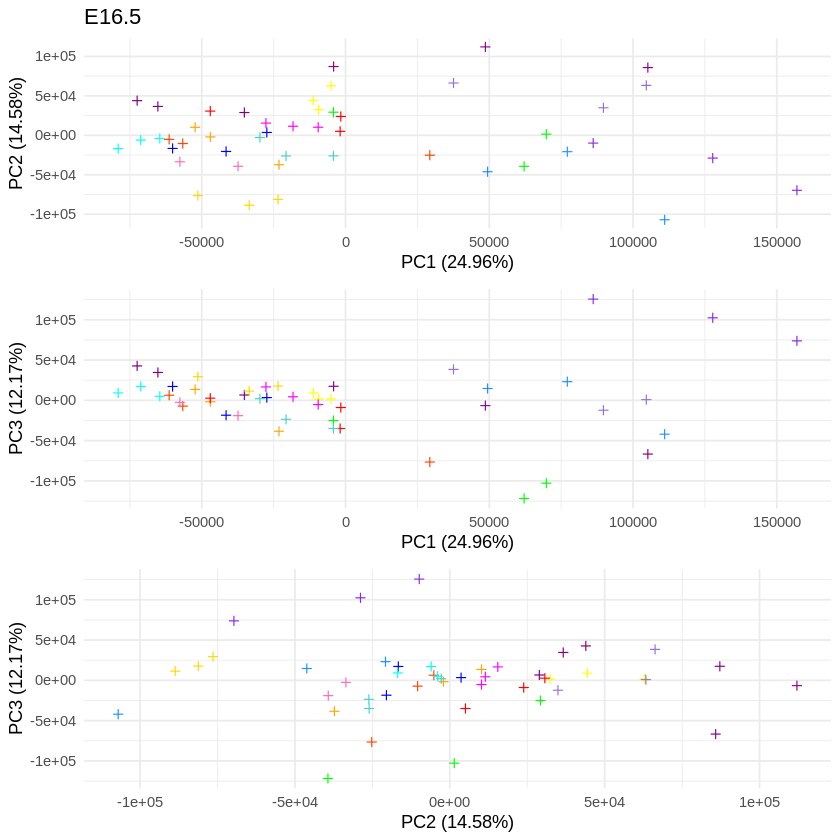

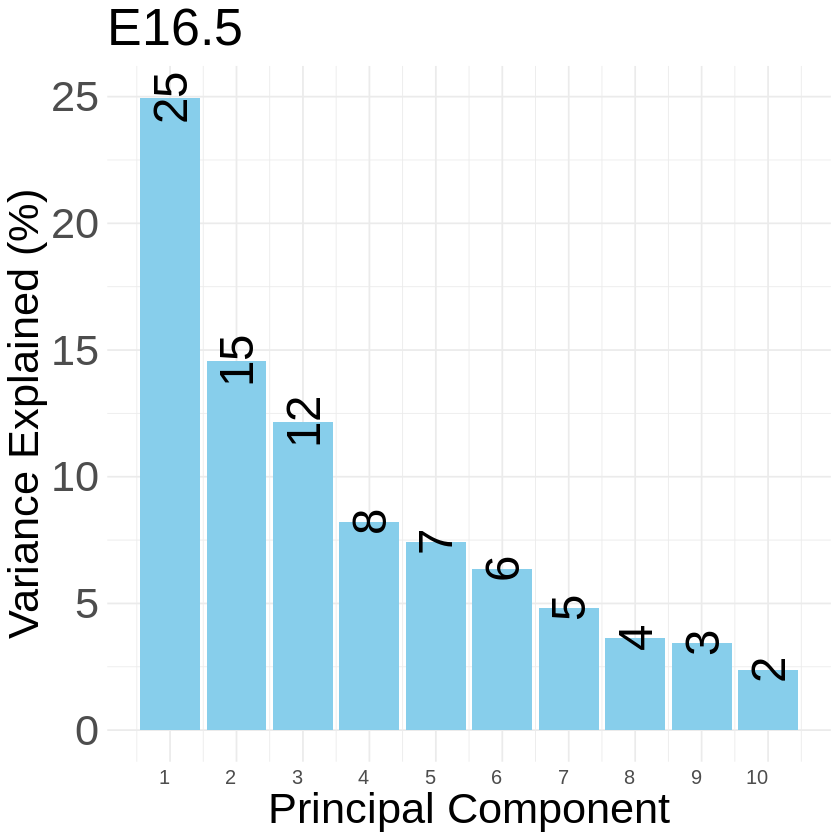

In [ ]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)




# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))



# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names
custom_colors <- c(
  '#FF0000',  # Bright Red
  '#00FF00',  # Bright Green
  '#0000FF',  # Bright Blue
  '#FF00FF',  # Bright Magenta
  '#FFFF00',  # Bright Yellow
  '#00FFFF',  # Bright Cyan
  '#FFA500',  # Orange
  '#800080',  # Purple
  '#FF4500',  # Deep Orange
  '#8B008B',  # Dark Magenta
  '#FF69B4',  # Hot Pink
  '#48D1CC',  # Teal
  '#9370DB',  # Lavender
  '#1E90FF',  # Royal Blue
  '#FFD700',  # Gold
  '#8A2BE2',  # Blue Violet
  '#FF6347',  # Tomato
  '#008000'   # Dark Green
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "E16.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100




# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "E16.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 






# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("E16.5_deseq2_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "E16.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("E16.5_variance_explained_bar_plot.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

In [ ]:
#check stabilty of PCA 
# Display the original PCA components
cat("Original PCA components:\n")
print(pca$rotation)

# Bootstrap function to reapply PCA
bootstrap_pca <- function(data, indices) {
  pca_sample <- prcomp(data[indices, ], center = TRUE, scale. = TRUE)
  return(pca_sample$rotation)
}

# Apply bootstrap
set.seed(1)
results <- boot(data = X, statistic = bootstrap_pca, R = 1000)

# Calculate the variability (standard deviation) of the PCA components
component_variability <- apply(results$t, 2, sd)

cat("\nVariability of PCA components across bootstrap samples:\n")
print(matrix(component_variability, nrow = 2, byrow = TRUE))

library(ggplot2)

# Convert the results to a data frame for plotting
component_var_df <- data.frame(
  Component = rep(c("PC1", "PC2"), each = 2),
  Axis = rep(c("X", "Y"), 2),
  Variability = as.vector(matrix(component_variability, nrow = 2, byrow = TRUE))
)

# Plotting the variability of PCA components
ggplot(component_var_df, aes(x = Component, y = Variability, fill = Axis)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(title = "Variability of PCA Components Across Bootstrap Samples",
       x = "Principal Component",
       y = "Variability (Standard Deviation)") +
  theme_minimal()


Original PCA components:
                        PC1           PC2           PC3           PC4
0610007P14Rik -1.129794e-02  1.466910e-02 -1.079971e-02  8.726217e-03
0610009B22Rik  1.520289e-04 -1.081747e-03  7.442857e-04 -7.983079e-04
0610010F05Rik  1.725712e-03  9.655679e-04  1.106576e-03 -1.058937e-03
0610010K14Rik -5.444273e-04 -1.479591e-03  8.164421e-04  1.222578e-03
0610037L13Rik -1.375759e-03  3.386515e-03 -1.534408e-03  2.759359e-03
0610040J01Rik -3.746985e-04 -6.469540e-04 -6.370370e-04 -7.911729e-04
1110002E22Rik  1.419273e-04 -1.141050e-04  2.363228e-05 -2.212303e-05
1110004F10Rik  2.856458e-03  5.668424e-04  3.392479e-03  3.297836e-03
1110008F13Rik  2.279940e-03 -9.475237e-04  5.004463e-04 -4.079036e-04
1110008L16Rik  7.040764e-04 -9.358608e-04  2.839593e-03  4.415973e-03
1110008P14Rik  4.596599e-05 -1.758344e-04 -3.520913e-04  3.808757e-04
1110017D15Rik -5.359097e-05 -5.326061e-05 -7.070979e-05  2.110702e-06
1110032A03Rik  3.020783e-04 -3.698307e-04  5.690723e-04  8.239446

ERROR: Error in boot(data = X, statistic = bootstrap_pca, R = 1000): could not find function "boot"


Warning message:
“ggrepel: 17522 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 17530 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


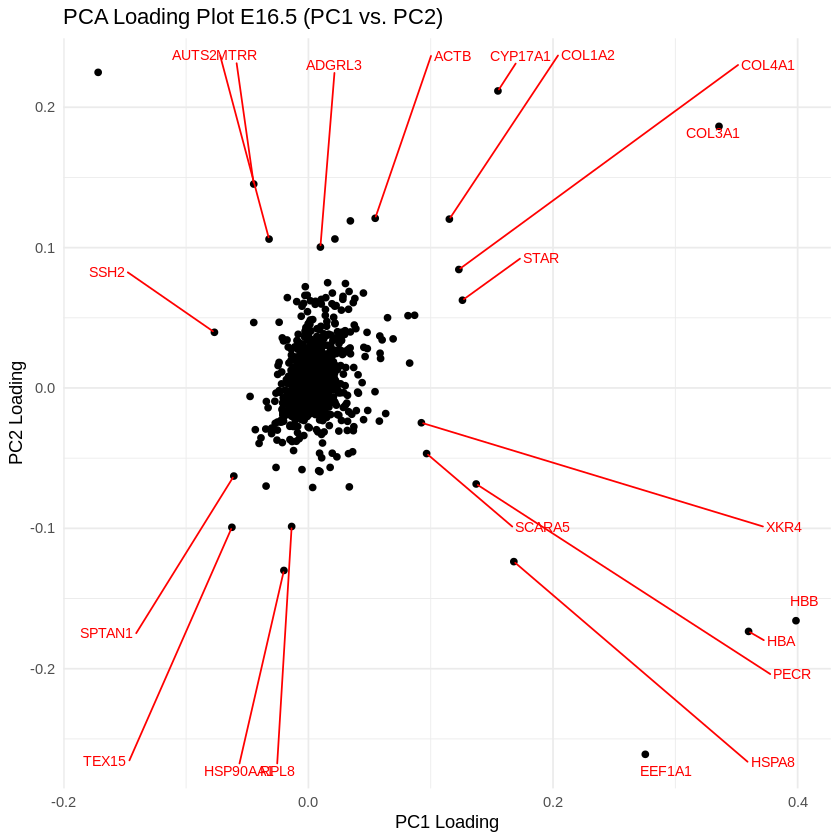

In [ ]:
library(ggrepel)

# Load required libraries
library(ggplot2)



# Perform PCA
pca_result <-  prcomp(t(norm_counts))

# Extract the loadings
loadings <- pca_result$rotation

# Calculate the ranking of loadings for each PC
rankings <- apply(loadings, 2, rank)

# Create a data frame for plotting
loadings_df <- data.frame(
  Variable = rownames(loadings),
  PC1 = loadings[, 1],
  PC2 = loadings[, 2],
  Ranking_PC1 = rankings[, 1],
  Ranking_PC2 = rankings[, 2]
)

# Create the scatter plot
plot <- ggplot(data = loadings_df, aes(x = PC1, y = PC2, label = Variable)) +
  geom_point() +
  geom_text_repel(
    size = 3,
    color = "red",
    box.padding = 0.5,
    force = 5  # Adjust the force parameter to control label dispersion
  ) +
  labs(title = "PCA Loading Plot E16.5 (PC1 vs. PC2)", x = "PC1 Loading", y = "PC2 Loading") +
  theme_minimal()

print(plot)
ggsave("E16.5_timepoint_PC1_PC2_loadibg.pdf", plot = plot, width = 5, height = 5)

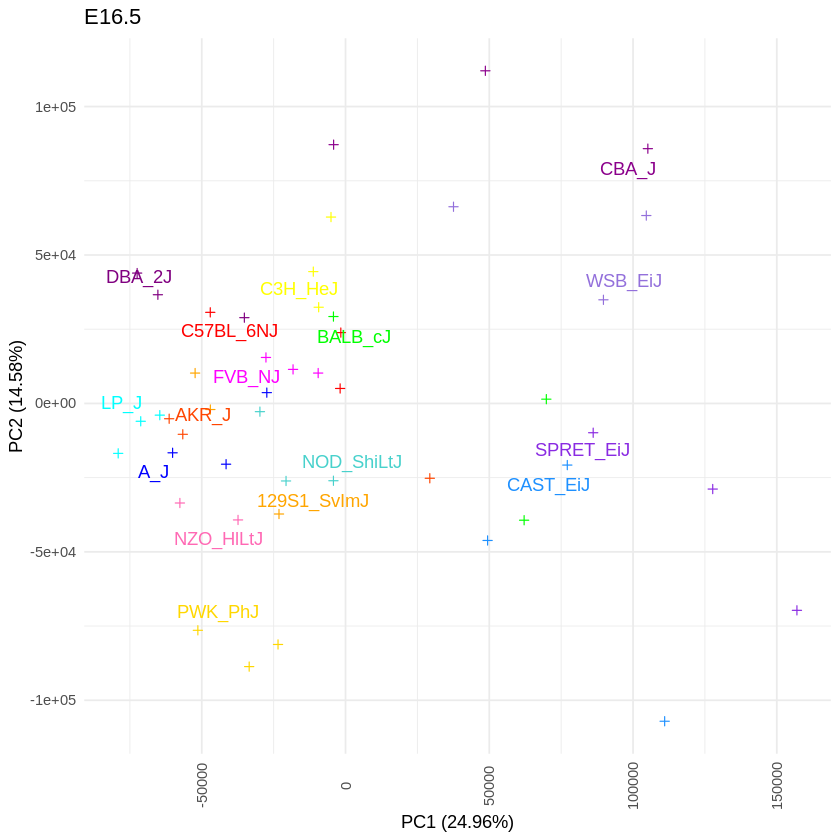

In [ ]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "E16.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains")  +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels





# Filter the data for specific unique strain values
selected_strains <- c('C57BL_6NJ','BALB_cJ','A_J','FVB_NJ','C3H_HeJ','LP_J','129S1_SvImJ','DBA_2J','AKR_J',
'CBA_J','NZO_HlLtJ',
'NOD_ShiLtJ',
'WSB_EiJ',
'CAST_EiJ',
'PWK_PhJ',
'SPRET_EiJ')
filtered_data <- pca_data %>%
  filter(Shape == "E16.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("E16.5_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 3, height = 5)

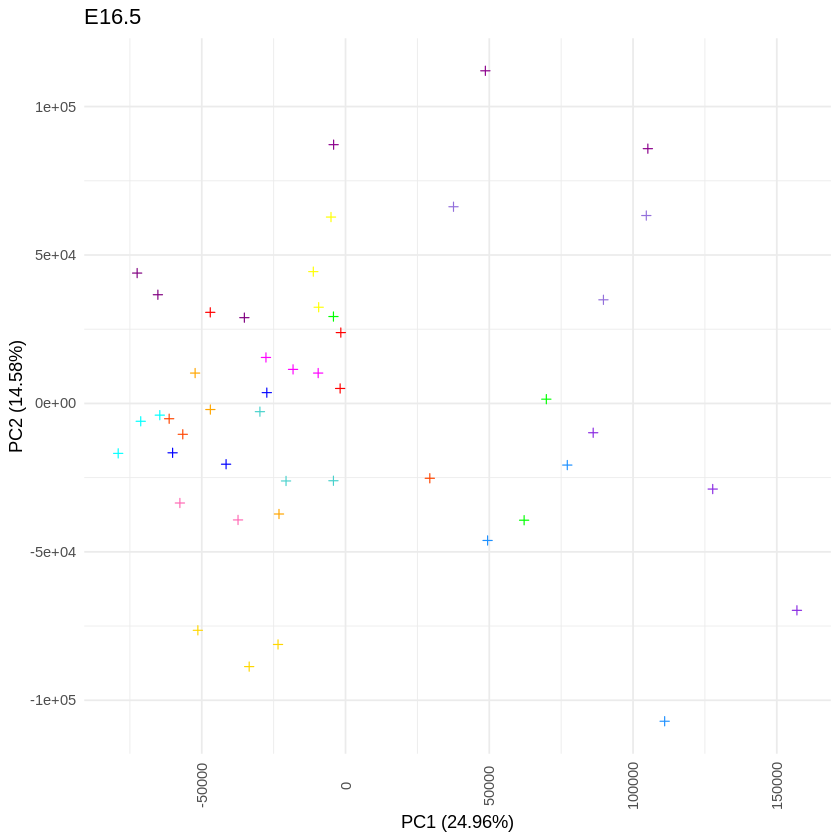

In [ ]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "E16.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() +
  labs(shape = "Timepoint") +
  labs(color = "Strains") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels


# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("E16.5_deseq2_PCA.pdf", pca_plot_pc1_pc2, width = 3, height = 5, units = "in")

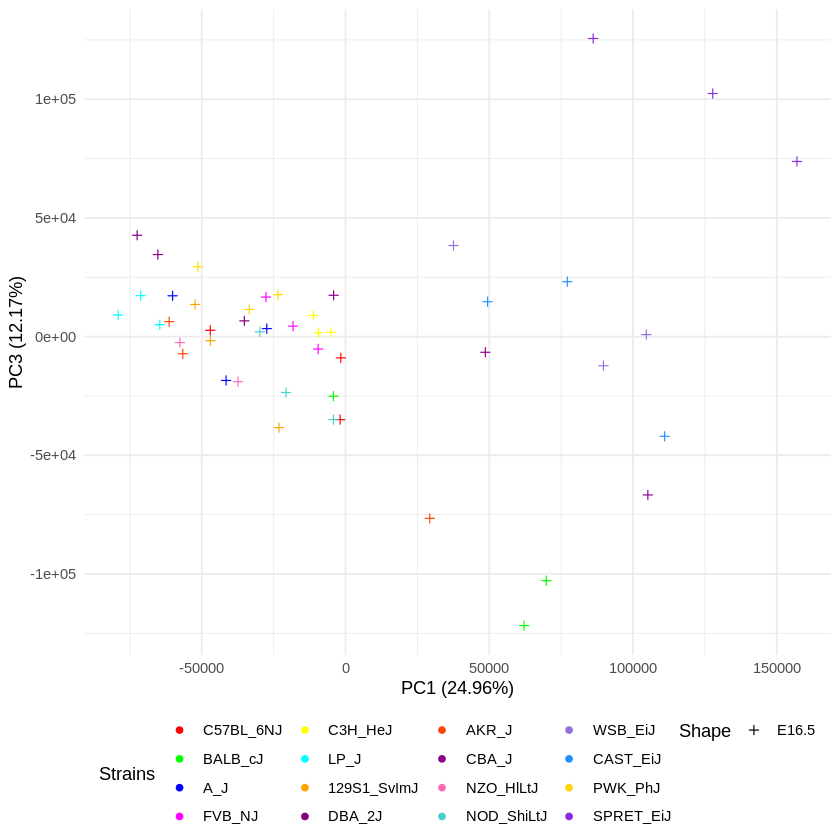

In [ ]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0.2, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


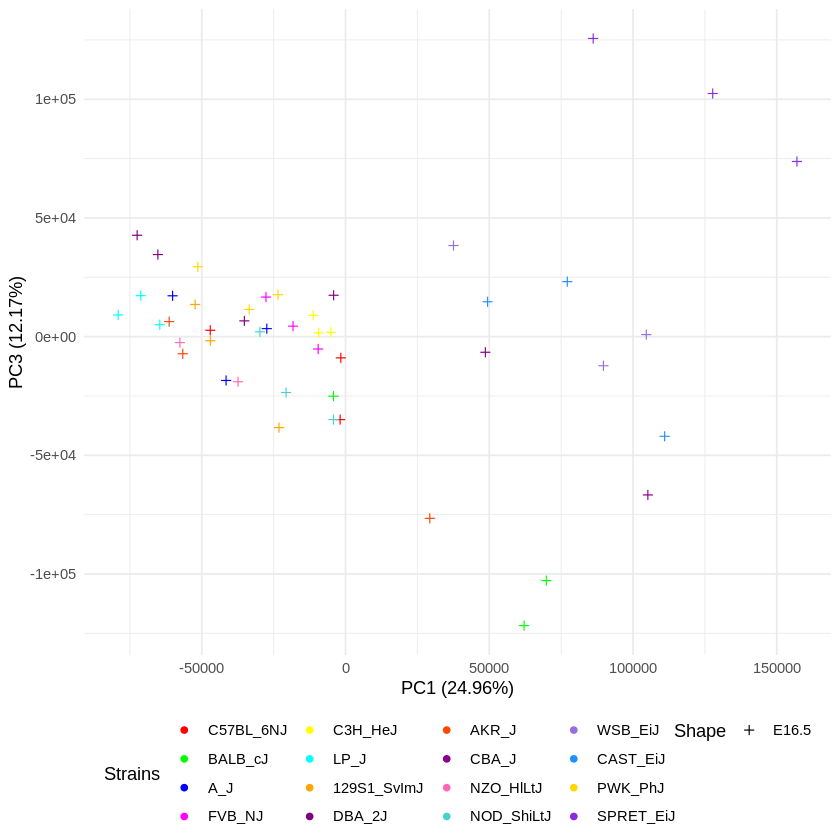

In [ ]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-E16.5.1,-12742.714,-30561.3671,-36476.8983,129S1_SvImJ-E16.5,26.86114,14.54142,12.68415,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.2,-44584.542,-5009.5068,-4118.1102,129S1_SvImJ-E16.5,26.86114,14.54142,12.68415,E16.5,129S1_SvImJ
129S1_SvImJ-E16.5.3,-53129.307,2626.6124,10154.6674,129S1_SvImJ-E16.5,26.86114,14.54142,12.68415,E16.5,129S1_SvImJ
A_J-E16.5.1,-54702.076,-18029.4308,15972.6432,A_J-E16.5,26.86114,14.54142,12.68415,E16.5,A_J
A_J-E16.5.2,-31312.120,-22718.6104,-23227.6764,A_J-E16.5,26.86114,14.54142,12.68415,E16.5,A_J
A_J-E16.5.3,-24211.888,-198.1929,2425.9733,A_J-E16.5,26.86114,14.54142,12.68415,E16.5,A_J
AKR_J-E16.5.1,-52733.775,-9762.5111,-8008.1283,AKR_J-E16.5,26.86114,14.54142,12.68415,E16.5,AKR_J
AKR_J-E16.5.2,43876.941,-22552.6598,-82150.2916,AKR_J-E16.5,26.86114,14.54142,12.68415,E16.5,AKR_J
AKR_J-E16.5.3,-58528.353,-8634.4196,2144.1384,AKR_J-E16.5,26.86114,14.54142,12.68415,E16.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


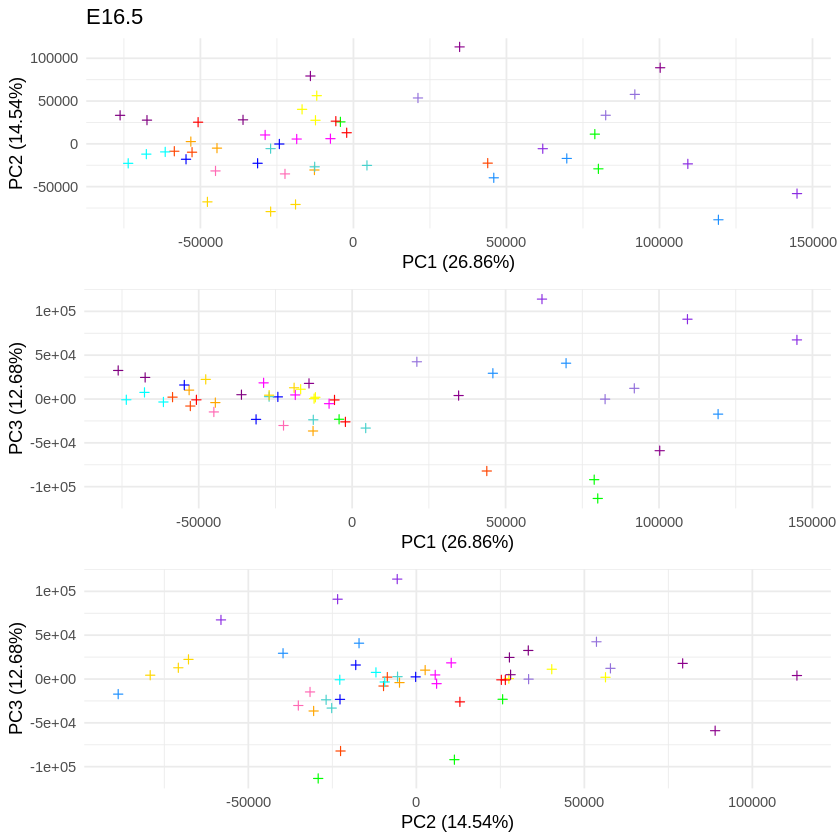

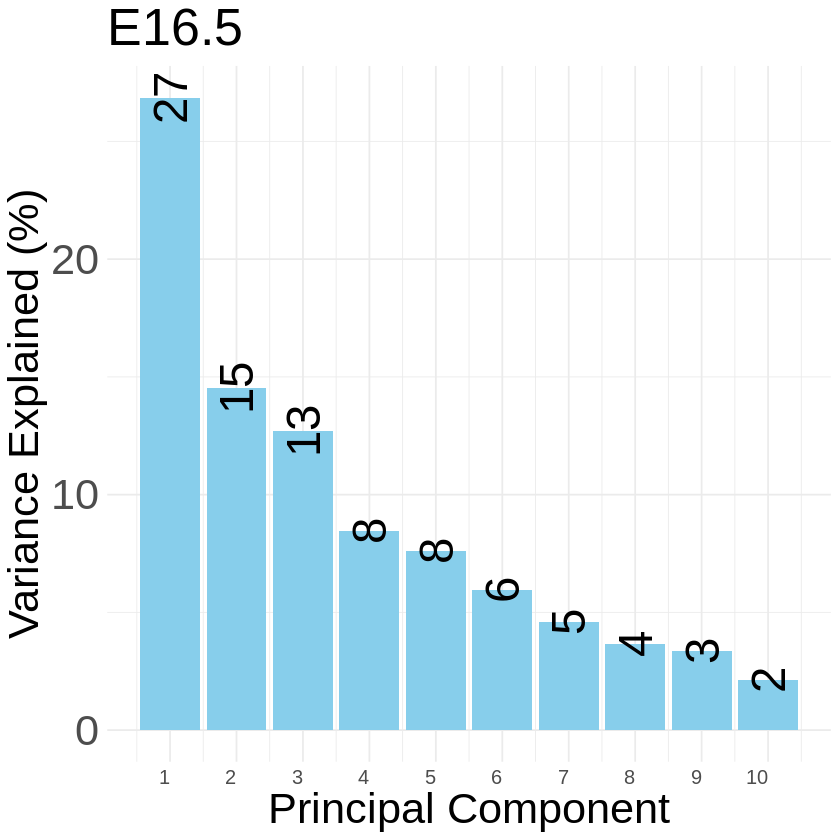

In [ ]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Calculate the row-wise variance and order rows by variance
row_variances <- apply(norm_counts, 1, var)
top_variants <- names(sort(row_variances, decreasing = TRUE))[1:500] #top 500 
subset_norm_counts <- norm_counts[top_variants, ]

# Perform PCA on the subsetted data
pca <- prcomp(t(subset_norm_counts))



# Sample data for illustration purposes
set.seed(123)




# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100


# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = samplenames,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "E16.5",
            ifelse(grepl("16.5", pca_data$Strains ), "E16.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100


# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "E16.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 




# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("E16.5_deseq2_PCA_top_500.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "E16.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("E16.5_variance_explained_bar_plot_top_500.pdf", variance_bar_plot, width = 3, height = 4, units = "in")


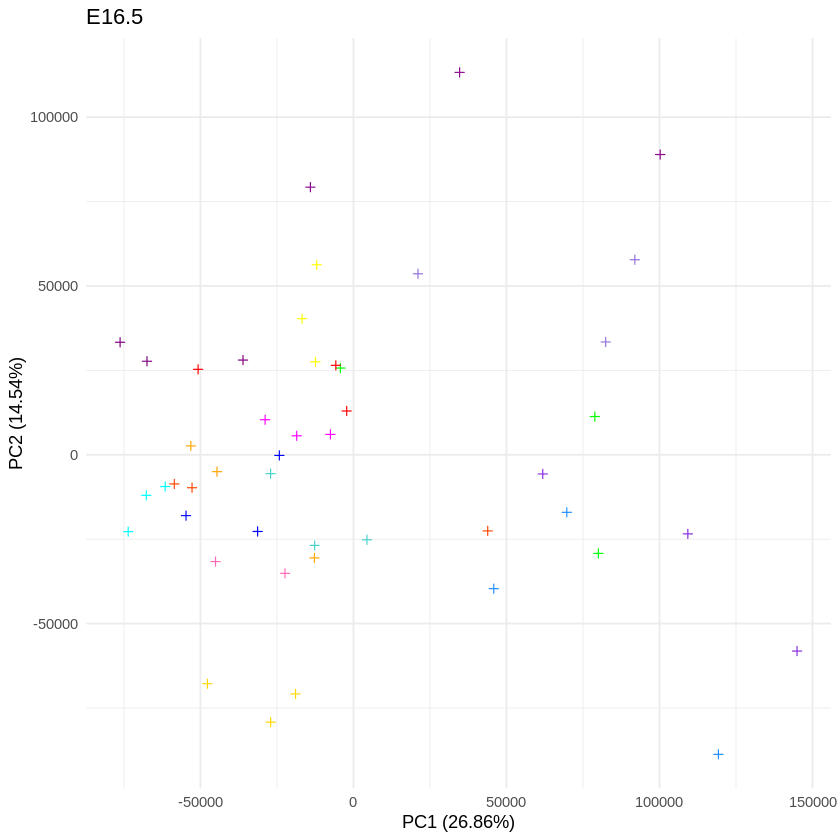

In [ ]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "E16.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "E16.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 
pca_plot_pc1_pc2

In [ ]:


pairwise_combinations  <- list(
  c('sample', 'C57BL_6NJ-E16.5', 'BALB_cJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'A_J-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'FVB_NJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'C3H_HeJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'LP_J-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', '129S1_SvImJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'DBA_2J-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'AKR_J-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'CBA_J-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'NZO_HlLtJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'NOD_ShiLtJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'WSB_EiJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'CAST_EiJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'PWK_PhJ-E16.5'),
  c('sample', 'C57BL_6NJ-E16.5', 'SPRET_EiJ-E16.5')
  # Add more contrasts here if needed
)
# Load required libraries
library(foreach)
library(doParallel)
library(EnhancedVolcano)  # Make sure you have this package installed

# Create a directory to save the plots
if (!dir.exists("volcano_plots")) {
    dir.create("volcano_plots")
}
# Combine results from all comparisons

library(edgeR)
library(EnhancedVolcano)
library(tidyverse)
library(DESeq2)
library(ggrepel)
library(kableExtra)

# Combine results from all comparisons
all_results <- data.frame()

# Loop through pairwise combinations
for (pair in pairwise_combinations) {
  condition1 <- pair[2]
  condition2 <- pair[3]
  
res <- results(cds, contrast = pair)
#res <- results(cds, contrast = c('sample', 'C57BL_6NJ-E16.5', 'BALB_cJ-E16.5'))
res

data <- data.frame(Genes = rownames(res),
                    logFC = res$log2FoldChange,
                     FDR = res$padj,
                     PValue = res$pvalue)

data <- data %>% 
    mutate(
      Expression = case_when(logFC >= log(2) & FDR <= 0.0001 ~ "Up-regulated",
                            logFC <= -log(2) & FDR <= 0.0001 ~ "Down-regulated",
                            TRUE ~ "Unchanged")
      )
data <- data %>% 
      mutate(
        Significance = case_when(
          abs(logFC) >= log(2) & FDR <= 0.05 & FDR > 0.01 ~ "FDR 0.05", 
          abs(logFC) >= log(2) & FDR <= 0.01 & FDR > 0.01 ~ "FDR 0.01",
          abs(logFC) >= log(2) & FDR <= 0.0001 ~ "FDR 0.0001", 
          TRUE ~ "Unchanged")
      )

    


all_genes <- bind_rows(
      data %>% 
        filter(Expression == 'Up-regulated') %>% 
        arrange(FDR, desc(abs(logFC))),
      data %>% 
        filter(Expression == 'Down-regulated') %>% 
        arrange(FDR, desc(abs(logFC))) 
    )


comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
all_results <- rbind(all_results, data.frame(Comparison = comparison_name,
                                                Expression = all_genes$Expression,
                                                Significance = all_genes$Significance,
                                                Genes = all_genes$Genes))
p2 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Expression), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_manual(values = c("dodgerblue3", "gray50", "firebrick3")) +
      guides(colour = guide_legend(override.aes = list(size=1.5)))  + theme_minimal()
p2 <-  p2 +
      geom_label_repel(
    data = all_genes[1:5,],
    mapping = aes(logFC, -log(FDR, 10), label = Genes),
    size = 2,
    box.padding = 0.2,
    point.padding = 0.5,
    segment.color = "grey50",
    segment.size = 0.5,
    box.draw = FALSE,  # Remove the box around labels
    label.size = NA,  # Show only the label text without background
    label.background = aes(fill = NA)  # Set the label background to transparent
  ) +
  theme(plot.title = element_text(hjust = 0.7))  +  # Center the plot title
  ggtitle(paste("vs", condition2))
 # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_up_down_volcano_plot.pdf", sep = ""), width = 3, height = 3)  # Adjust width and height as needed
    print(p2)
    dev.off()  # Close the PDF device

p3 <- ggplot(data, aes(logFC, -log(FDR,10))) +
      geom_point(aes(color = Significance), size = 2/5) +
      xlab(expression("log"[2]*"FC")) + 
      ylab(expression("-log"[10]*"FDR")) +
      scale_color_viridis_d() +
      guides(colour = guide_legend(override.aes = list(size=1.5))) +theme_minimal()
p3 <- p3 +
  geom_label_repel(
    data = all_genes[1:5,],
    mapping = aes(logFC, -log(FDR, 10), label = Genes),
    size = 2,
    box.padding = 0.2,
    point.padding = 0.5,
    segment.color = "grey50",
    segment.size = 0.5,
    box.draw = FALSE,  # Remove the box around labels
    label.size = NA,  # Show only the label text without background
    label.background = aes(fill = NA)  # Set the label background to transparent
  ) +
  theme(plot.title = element_text(hjust = 0.7))  +  # Center the plot title
  ggtitle(paste("vs", condition2))
    # Save the plot as a PDF file
    pdf(paste("volcano_plots/", condition1, "_vs_", condition2, "_singnificant_volcano_plot.pdf", sep = ""), width = 3, height = 3)  # Adjust width and height as needed
    print(p3)
    dev.off() 
}


Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 706 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 706 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 366 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :
“Ignoring unknown parameters: `box.draw` and `label.background`”
Warning message:
“Removed 366 rows containing missing values (`geom_point()`).”
Warning message in geom_label_repel(data = all_genes[1:5, ], mapping = aes(logFC, :


In [ ]:
# Combine top_genes data from all comparisons
combined_top_genes <-  all_results
combined_top_genes



Comparison,Expression,Significance,Genes
<chr>,<chr>,<chr>,<chr>
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,SLC22A14
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,FAM221B
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,OSBPL10
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,PLA2R1
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,Ccl27a
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,SNX14
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,NIPA1
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,GPATCH11
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,Up-regulated,FDR 0.0001,AXDND1


In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork) 

# Summarize the data for plotting
summary_data <- all_results %>%
  group_by(Comparison, Expression) %>%
  tally() %>%
  spread(key = Expression, value = n, fill = 0)
summary_data

pair_sets <- c("C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5",
  "C57BL_6NJ-E16.5_vs_A_J-E16.5",
  "C57BL_6NJ-E16.5_vs_FVB_NJ-E16.5",
  "C57BL_6NJ-E16.5_vs_C3H_HeJ-E16.5",
  "C57BL_6NJ-E16.5_vs_LP_J-E16.5",
  "C57BL_6NJ-E16.5_vs_129S1_SvImJ-E16.5",
  "C57BL_6NJ-E16.5_vs_DBA_2J-E16.5",
  "C57BL_6NJ-E16.5_vs_AKR_J-E16.5",
  "C57BL_6NJ-E16.5_vs_CBA_J-E16.5",
   "C57BL_6NJ-E16.5_vs_NZO_HlLtJ-E16.5",
  "C57BL_6NJ-E16.5_vs_NOD_ShiLtJ-E16.5",
  "C57BL_6NJ-E16.5_vs_WSB_EiJ-E16.5",
  "C57BL_6NJ-E16.5_vs_CAST_EiJ-E16.5",
  "C57BL_6NJ-E16.5_vs_PWK_PhJ-E16.5",
  "C57BL_6NJ-E16.5_vs_SPRET_EiJ-E16.5")




# Create separate plots for upregulated and downregulated genes
upregulated_plot <- ggplot(summary_data, aes(x =  factor(Comparison, levels = pair_sets),, y = `Up-regulated`, fill = "Up-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Up-regulated" = "blue")) +
  xlab("Comparison") +
  ylab("# of Genes") +
  ggtitle("# of Significant Up-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),plot.title = element_text(size = 10),
        legend.title = element_blank(),
        legend.position = "bottom")+
  geom_text(aes(y = `Up-regulated`, label = `Up-regulated`),angle = 90, vjust = 0.5,hjust=-0.1, size = 3, color = "black",nudge_y = 5) 

downregulated_plot <- ggplot(summary_data, aes(x = factor(Comparison, levels = pair_sets), y = `Down-regulated`, fill = "Down-regulated")) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("Down-regulated" = "red")) +
  xlab("Comparison") +
  ylab("# of Genes") +
  ggtitle("# of Significant Down-regulated Genes") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1),plot.title = element_text(size = 10),
        legend.title = element_blank(),
        legend.position = "bottom") +
  geom_text(aes(y = `Down-regulated`, label = `Down-regulated`),angle = 90, vjust = 0.5,hjust=-0.1, size = 3, color = "black",nudge_y = 5)

# Print the separate plots
# Open a PDF device to save the plot
pdf("P20.5_upreglated_count_bar_plot.pdf", width = 6, height = 4)  # Adjust width and height as needed
print(upregulated_plot)
dev.off()
pdf("P20.5_downreglated_count_bar_plot.pdf", width = 6, height = 4)  # Adjust width and height as needed
print(downregulated_plot)
dev.off()

y_range <- range(0,4000)

# Apply the same y-axis range to both plots
upregulated_plot <- upregulated_plot +
  coord_cartesian(ylim = y_range)

downregulated_plot <- downregulated_plot +
  coord_cartesian(ylim = y_range)

# Remove legends from both plots
upregulated_plot_no_legend <- upregulated_plot +
  theme(legend.position = "none")

downregulated_plot_no_legend <- downregulated_plot +
  theme(legend.position = "none",
        axis.title.x = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

# Combine both plots side by side
combined_plots <-  downregulated_plot_no_legend + upregulated_plot_no_legend 
# Save the combined plot to a PDF device


# Combine both plots side by side
combined_plots <-  downregulated_plot_no_legend +upregulated_plot_no_legend + plot_layout(ncol = 1)

# Save the combined plot to a PDF device
pdf("E16.5_up_down_combined_plots.pdf", width = 3.5, height = 6)  # Adjust width and height as needed
print(combined_plots)
dev.off()




Comparison,Down-regulated,Up-regulated
<chr>,<dbl>,<dbl>
C57BL_6NJ-E16.5_vs_129S1_SvImJ-E16.5,348,357
C57BL_6NJ-E16.5_vs_A_J-E16.5,531,548
C57BL_6NJ-E16.5_vs_AKR_J-E16.5,460,526
C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5,486,286
C57BL_6NJ-E16.5_vs_C3H_HeJ-E16.5,372,1266
C57BL_6NJ-E16.5_vs_CAST_EiJ-E16.5,1075,820
C57BL_6NJ-E16.5_vs_CBA_J-E16.5,342,1344
C57BL_6NJ-E16.5_vs_DBA_2J-E16.5,416,410
C57BL_6NJ-E16.5_vs_FVB_NJ-E16.5,441,373


png 
  2

png 
  2

png 
  2

In [ ]:
unique(combined_top_genes$Comparison)

[1] "C57BL_6NJ-E16.5_vs_BALB_cJ-E16.5"    
 [2] "C57BL_6NJ-E16.5_vs_A_J-E16.5"        
 [3] "C57BL_6NJ-E16.5_vs_FVB_NJ-E16.5"     
 [4] "C57BL_6NJ-E16.5_vs_C3H_HeJ-E16.5"    
 [5] "C57BL_6NJ-E16.5_vs_LP_J-E16.5"       
 [6] "C57BL_6NJ-E16.5_vs_129S1_SvImJ-E16.5"
 [7] "C57BL_6NJ-E16.5_vs_DBA_2J-E16.5"     
 [8] "C57BL_6NJ-E16.5_vs_AKR_J-E16.5"      
 [9] "C57BL_6NJ-E16.5_vs_CBA_J-E16.5"      
[10] "C57BL_6NJ-E16.5_vs_NZO_HlLtJ-E16.5"  
[11] "C57BL_6NJ-E16.5_vs_NOD_ShiLtJ-E16.5" 
[12] "C57BL_6NJ-E16.5_vs_WSB_EiJ-E16.5"    
[13] "C57BL_6NJ-E16.5_vs_CAST_EiJ-E16.5"   
[14] "C57BL_6NJ-E16.5_vs_PWK_PhJ-E16.5"    
[15] "C57BL_6NJ-E16.5_vs_SPRET_EiJ-E16.5"

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)
library(ggplot2)

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_upregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

library(UpSetR)

# Open a PDF device to save the plot
pdf("E16.5_upregulated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed





# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_sets ,nsets = 13,point.size = 2, line.size = 1,keep.order = TRUE,order.by = "freq",
 number.angles = 0, mainbar.y.label = "Genes Intersections (Significant-Up-regulated)", sets.x.label = "# of Genes",cutoff = 1) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()


png 
  2

In [ ]:
# Load required libraries
library(dplyr)
library(tidyr)
library(UpSetR)

# Filter data for common upregulated and downregulated genes
common_downregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

# Group by comparison and create a binary column for each gene
binary_data <- common_downregulated  %>%
  select(Comparison, Genes) %>%
  group_by(Comparison) %>%
  mutate(present = 1) %>%
  ungroup() %>%
  pivot_wider(names_from = Comparison, values_from = present, values_fill = 0)


# Convert to a data frame
binary_data <- as.data.frame(binary_data)
# Remove the 'Genes' column
rownames(binary_data) <- binary_data$Genes
binary_data$Genes <- NULL

library(UpSetR)




# Open a PDF device to save the plot
pdf("E16.5_downreglated_upset_plot.pdf", width = 10, height = 6)  # Adjust width and height as needed

# Create the UpSet plot
upset_plot <- upset(binary_data, sets = pair_sets  ,nsets = 13,point.size = 2, line.size = 1, ,keep.order = TRUE,order.by = "freq",
 number.angles = 0, mainbar.y.label = "Genes Intersections (Significant-Down-regulated)", sets.x.label = "# of Genes",cutoff = 7) # Adjust the height ratio)
# Display the UpSet plot
print(upset_plot)
# Save and close the PDF device
dev.off()

png 
  2

In [ ]:

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Up-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_sets)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) 

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'


# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing


# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
  # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_upset_upregulated_", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")


  if(!is.null(go_enrichment_list[[i]]$p.adjust)){

  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1)) + theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_E16.5_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 3, width = 10)
}}


Warning message:
“Removed 8 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 8 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 4 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 3 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 7 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 10 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 2 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 17 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 14 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 15 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 16 rows containing missing values (`position_stack()`).”
Warning me

In [ ]:

# Filter data for common upregulated and downregulated genes
common_upregulated <- combined_top_genes %>%
  filter(Expression == "Down-regulated")

common_upregulated <-common_upregulated %>%
  filter(Comparison %in% pair_sets)

up_gene_list <- data.frame(gene=unique(common_upregulated$Genes))

upregulated_int <- lapply(up_gene_list$gene,function(x){
  # pull the name of the intersections
  intersection <- common_upregulated %>% 
    dplyr::filter(Genes==x) %>% 
    arrange(Comparison) %>% 
    pull("Comparison") %>% 
    paste0(collapse = "|")
      # build the dataframe
  data.frame(Genes = x,int = intersection)
}) %>% 
  bind_rows()
top_30_intersections <- upregulated_int %>%
  group_by(int) %>%
  summarise(num_genes = n()) %>%
  arrange(desc(num_genes)) 

genes_by_top_intersections <- upregulated_int %>%
  filter(int %in% top_30_intersections$int) %>%
  group_by(int) %>%
  summarise(gene_list = paste(Genes, collapse = ', '))


# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)


# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 30  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = genes_by_top_intersections$int) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  # Filter data for common upregulated and downregulated genes
  DEGs <- unlist(strsplit(genes_by_top_intersections[genes_by_top_intersections$int == pair, ]$gene_list, ", "))
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", # BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots_upset")) {
  dir.create("go-ontology-plots_upset")
}
# Iterate through the pairwise combinations sequentially
for (i in 1:length(genes_by_top_intersections$int)) {
  comparison_name <- paste(genes_by_top_intersections$int[i])
  # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_upset_downegulated_", i, ".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1)) + theme(plot.title = element_text(size = 2))

  # Save the plot
  filename <- paste0("go-ontology-plots_upset/", gsub("\\|", "_", i), "_E16.5.5_Down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 3, width = 10)
}}

Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 14 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 6 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 10 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 17 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 9 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 10 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 13 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 12 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 18 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 18 rows containing missing values (`position_stack()`).”
Warnin

In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'





# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)



# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[2]
  condition2 <- pair[3]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Up-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation


# Simplify the GO enrichment results to combine similar terms
simplified_results <- lapply(go_enrichment_list, function(go_result) {
  if (nrow(go_result) > 0) {
    simplify(go_result, measure = "Wang", cutoff = 0.7, by = "p.adjust", select_fun = min)
  } else {
    return(go_result)
  }
})

simplified_results[[1]]




#
# over-representation test
#
#...@organism 	 Mus musculus 
#...@ontology 	 BP 
#...@keytype 	 SYMBOL 
#...@gene 	 chr [1:286] "SLC22A14" "FAM221B" "OSBPL10" "PLA2R1" "Ccl27a" "SNX14" ...
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...1 enriched terms found
'data.frame':	1 obs. of  9 variables:
 $ ID         : chr "GO:0052547"
 $ Description: chr "regulation of peptidase activity"
 $ GeneRatio  : chr "5/31"
 $ BgRatio    : chr "466/28564"
 $ pvalue     : num 0.000135
 $ p.adjust   : num 0.0456
 $ qvalue     : num 0.0376
 $ geneID     : chr "Cst9/Gpi1/Khdc1b/Cst13/Nlrp1a"
 $ Count      : int 5
#...Citation
 T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu.
 clusterProfiler 4.0: A universal enrichment tool for interpreting omics data.
 The Innovation. 2021, 2(3):100141 


In [ ]:
simplified_results[[15]]$Description

[1] "unsaturated fatty acid metabolic process"       
 [2] "arachidonic acid metabolic process"             
 [3] "icosanoid metabolic process"                    
 [4] "olefinic compound metabolic process"            
 [5] "xenobiotic metabolic process"                   
 [6] "activation of immune response"                  
 [7] "response to interferon-beta"                    
 [8] "negative regulation of viral genome replication"
 [9] "response to xenobiotic stimulus"                
[10] "viral genome replication"                       
[11] "response to interferon-alpha"                   
[12] "response to type II interferon"                 
[13] "positive regulation of chemokine production"    
[14] "sodium-independent organic anion transport"     
[15] "response to virus"                              
[16] "interferon-mediated signaling pathway"          
[17] "regulation of humoral immune response"          
[18] "chemokine production"                           
[19] "type I interferon-mediated signaling pathway"   
[20] "defense response to virus"                      
[21] "defense response to symbiont"                   
[22] "amino sugar catabolic process"                  
[23] "regulation of peptidase activity"               
[24] "antifungal innate immune response"

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[2]
  condition2 <- pair[3]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]
  # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_upregulated_",pair[1],"_" , pair[2],"_",pair[3]  ,".csv")
  write.csv(as.data.frame(go_enrichment_list[[i]]), csv_filename, row.names = FALSE)

   # Append the comparison_name at the end of the file on a new line
  #cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")


  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Up-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_up_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}


Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 8 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 3 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 1 rows containing missing values (`position_stack()`).”


In [ ]:
# Load necessary packages
library(clusterProfiler)
library(DESeq2)
library(doParallel)

# Assuming you have performed differential expression analysis using DESeq2 and have a DESeqDataSet named 'dds'

# Set up parallel processing
num_cores <- 20  # Number of cores or processors to use
cl <- makeCluster(num_cores)
registerDoParallel(cl)

# Your code for gene ontology enrichment analysis in parallel
go_enrichment_list <- foreach(pair = pairwise_combinations) %dopar% {
  library(clusterProfiler)
  library(DESeq2)
  library(org.Mm.eg.db)
  condition1 <- pair[2]
  condition2 <- pair[3]
  comparison_name <- paste(condition1, "_vs_", condition2, sep = "")
  # Filter data for common upregulated and downregulated genes
  common_upregulated <- combined_top_genes %>%
      filter(Expression == "Down-regulated" & Comparison == comparison_name )
  DEGs <- common_upregulated$Genes
  print(common_upregulated$Genes)
  enrichGO(gene = DEGs,
           OrgDb = org.Mm.eg.db,
           keyType = "SYMBOL",
           ont = "BP", #BP for Biological Process ontology; you can use "MF" or "CC" for Molecular Function or Cellular Component?
           pAdjustMethod = "BH",
           pvalueCutoff = 0.05)
}

# Stop parallel processing
stopCluster(cl)
registerDoSEQ()  # Reset to sequential processing

# Now go_enrichment_list contains the results from the parallel computation

# Simplify the GO enrichment results to combine similar terms
simplified_results <- lapply(go_enrichment_list, function(go_result) {
  if (nrow(go_result) > 0) {
    simplify(go_result, measure = "Wang", cutoff = 0.7, by = "p.adjust", select_fun = min)
  } else {
    return(go_result)
  }
})

simplified_results[[1]]



#
# over-representation test
#
#...@organism 	 Mus musculus 
#...@ontology 	 BP 
#...@keytype 	 SYMBOL 
#...@gene 	 chr [1:486] "TMPRSS11D" "fgfr1op" "SMAP1" "CSF2RA" "RRS1" "C1orf43" ...
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...27 enriched terms found
'data.frame':	27 obs. of  9 variables:
 $ ID         : chr  "GO:0009615" "GO:0035456" "GO:0045069" "GO:0035458" ...
 $ Description: chr  "response to virus" "response to interferon-beta" "regulation of viral genome replication" "cellular response to interferon-beta" ...
 $ GeneRatio  : chr  "11/64" "6/64" "6/64" "5/64" ...
 $ BgRatio    : chr  "366/28564" "71/28564" "103/28564" "59/28564" ...
 $ pvalue     : num  5.33e-10 1.27e-08 1.20e-07 2.20e-07 4.06e-07 ...
 $ p.adjust   : num  3.65e-07 4.36e-06 2.74e-05 3.76e-05 4.07e-05 ...
 $ qvalue     : num  2.95e-07 3.52e-06 2.22e-05 3.04e-05 3.29e-05 ...
 $ geneID     : chr  "Apobec3/Oas1f/Irgm1/Irgm2/Oasl2/Gbp2b/Gbp7/Lgals9/Nlrp9b/Oasl1/Ifitm3" "Oas1f/Irgm1/Irgm2/Gbp2b/Gbp7/Ifitm3"

In [ ]:
simplified_results[[14]]$Description

[1] "fatty acid metabolic process"

In [ ]:
go_enrichment_list[[14]]$Description

[1] "fatty acid metabolic process"

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Create the directory if it doesn't exist
if (!file.exists("go-ontology-plots")) {
  dir.create("go-ontology-plots")
}

# Combine the results from all pairwise combinations
# all_enrichment_results <- do.call("rbind", go_enrichment_list)
# all_enrichment_results <- go_enrichment_list

# Iterate through the pairwise combinations sequentially
for (i in 1:length(pairwise_combinations)) {
  pair <- pairwise_combinations[[i]]
  condition1 <- pair[1]
  condition2 <- pair[2]
  comparison_name <- paste(pair[1],"_" , pair[2],"_",pair[3], sep = "")

  # Filter the enrichment results for the specific comparison
  # comparison_results <- all_enrichment_results[[i]]
  # Write the data frame to a CSV file
  csv_filename <- paste0("GO_Enrichment_Result_downregulated_" , pair[1],"_" , pair[2],"_",pair[3], ".csv")
  #write.csv(as.data.frame(go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ]), csv_filename, row.names = FALSE)
  write.csv(as.data.frame(go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]), csv_filename, row.names = FALSE)
  go_enrichment_list[[i]]
  # Append the comparison_name at the end of the file on a new line
  #cat(comparison_name, file = csv_filename, append = TRUE, sep = "\n")

  # Sort the results by adjusted p-value
  # sorted_results <- comparison_results[order(comparison_results$p.adjust), ]
  if(!is.null(go_enrichment_list[[i]]$p.adjust)){
  # Plot the top enriched terms (let's say top 20)
  top_terms <- go_enrichment_list[[i]][order(go_enrichment_list[[i]]$p.adjust), ][1:20, ]

  # Create a bar plot using ggplot2
  p <- ggplot(top_terms, aes(x = -log10(pvalue), y = reorder(Description, -log10(pvalue)))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  labs(title = comparison_name,
       x = "log10(pValue)",
       y = "Enriched Terms (Significant-Down-Regulated)") +
  theme_minimal() +
  theme(axis.text.y = element_text(angle = 0, hjust = 1))

  # Save the plot
  filename <- paste0("go-ontology-plots/", comparison_name, "_down_regulated_barplot.pdf")
  ggsave(filename, plot = p, device = "pdf", height = 4, width = 8)
}}


Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 15 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 18 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 19 rows containing missing values (`position_stack()`).”
Warning message:
“Removed 20 rows containing missing values (`position_stack()`).”
